In [1]:
# Pra mim (becky): conda activate icd_projeto
# conda env export > environment.yml
# conda env create -f environment.yml

# Importações

In [83]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.graph_objects as dict_to_plotly
from plotly.subplots import make_subplots

import openpyxl
import joblib
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

# Funções

In [84]:
def region(df):
    """
    Agrupa os estados por regiões
    """
    mapeamento_regioes = {
    # Região Norte
    'AM': 'Norte', 'PA': 'Norte', 'RO': 'Norte', 'RR': 'Norte', 'AC': 'Norte', 'AP': 'Norte', 'TO': 'Norte',
    
    # Região Nordeste
    'MA': 'Nordeste', 'PI': 'Nordeste', 'CE': 'Nordeste', 'RN': 'Nordeste', 'PB': 'Nordeste', 'PE': 'Nordeste', 
    'AL': 'Nordeste', 'SE': 'Nordeste', 'BA': 'Nordeste',
    
    # Região Centro-Oeste
    'MT': 'Centro-Oeste', 'MS': 'Centro-Oeste', 'GO': 'Centro-Oeste', 'DF': 'Centro-Oeste',
    
    # Região Sudeste
    'SP': 'Sudeste', 'RJ': 'Sudeste', 'MG': 'Sudeste', 'ES': 'Sudeste',
    
    # Região Sul
    'PR': 'Sul', 'RS': 'Sul', 'SC': 'Sul',
    
    # Caso especial do agregado nacional presente na base de dados
    'TOTAL': 'Nacional'
}

    df['region'] = df['state'].map(mapeamento_regioes)

    print("Sucesso: Coluna de regiões criada")
    return df

In [85]:
def classificar_onda(date):
    # Antes da vacinação em massa
    if date < pd.Timestamp('2021-01-17'):
        return '1_pre_vacinacao'
    # Predominância da Gamma (P.1)
    elif date < pd.Timestamp('2021-08-15'):
        return '2_gamma'
    # Predominância da Delta
    elif date < pd.Timestamp('2021-12-15'):
        return '3_delta'
    # Explosão e predominância da Omicron
    elif date < pd.Timestamp('2022-07-01'):
        return '4_omicron'
    # Queda após grandes ondas de transmissão
    else:
        return '5_pos_pico'

In [86]:
def aplicar_medias_moveis(df, colunas_alvo=['newCases', 'newDeaths'], janelas=[7, 15, 30]):
    """
    Faz a média móvel para as colunas de novos casos e mortes nas janelas de 7, 15 e 30 dias
    """
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values(by=['state', 'date']).reset_index(drop=True)
    
    for coluna in colunas_alvo:
        for janela in janelas:
            nome_nova_coluna = f"{coluna}_mm{janela}"
            # Aplica o cálculo agrupado por estado
            df[nome_nova_coluna] = df.groupby('state')[coluna].transform(
                lambda x: x.rolling(window=janela, min_periods=1).mean()
            )
            
    print(f"Sucesso: Médias móveis aplicadas para as colunas {colunas_alvo} nas janelas {janelas}.")
    return df

In [87]:
def defasagem(df,colunas_alvo=['newCases'], lags=[7, 14, 21]):
    """
    Faz o cálculo da defasagem na coluna de novos casos para 7, 14 e 21 dias atrás
    """
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values(by=['state', 'date']).reset_index(drop=True)

    for coluna in colunas_alvo:
        for lag in lags:
            nome_nova_coluna = f"{coluna}_lag{lag}"
            # O .shift(lag) move os dados daquela coluna 'X' dias para a frente
            df[nome_nova_coluna] = df.groupby('state')[coluna].shift(lag)
            
    print(f"Sucesso: Lags de {lags} dias aplicados para as colunas {colunas_alvo}.")
    return df

# Amostragem

In [88]:
data = pd.read_csv(r"..\data\raw\cases-brazil-states.csv")

In [89]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30842 entries, 0 to 30841
Data columns (total 26 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   epi_week                               30842 non-null  int64  
 1   date                                   30842 non-null  object 
 2   country                                30842 non-null  object 
 3   state                                  30842 non-null  object 
 4   city                                   30842 non-null  object 
 5   newDeaths                              30842 non-null  int64  
 6   deaths                                 30842 non-null  int64  
 7   newCases                               30842 non-null  int64  
 8   totalCases                             30842 non-null  int64  
 9   deathsMS                               30842 non-null  int64  
 10  totalCasesMS                           30842 non-null  int64  
 11  de

In [90]:
# Divisão em uma faixa trimestral pelo conjunto estado-periodo
data['date'] = pd.to_datetime(data['date'])
data['periodo_temporal'] = data['date'].dt.to_period('Q')

In [91]:
# Estrato através do cruzamento entre Estado (state) e Período Temporal
data['estrato'] = data['state'].astype(str) + "_" + data['periodo_temporal'].astype(str)

In [92]:
# Amostragem de 30%
sub = data.groupby('estrato', group_keys=False).sample(frac=0.3, random_state=42)
print(f"Tamanho da subamostra obtida (30%): {sub.shape[0]} linhas.")

Tamanho da subamostra obtida (30%): 9293 linhas.


In [93]:
sub.sort_values(by='date').tail(50)

,epi_week,date,country,state,city,newDeaths,deaths,newCases,totalCases,deathsMS,...,vaccinated,vaccinated_per_100_inhabitants,vaccinated_second,vaccinated_second_per_100_inhabitants,vaccinated_single,vaccinated_single_per_100_inhabitants,vaccinated_third,vaccinated_third_per_100_inhabitants,periodo_temporal,estrato
30665,311,2023-03-12,Brazil,RN,TOTAL,0,8715,0,585935,8715,...,2977503.0,84.90527,2772139.0,79.04919,69006.0,1.96775,2030138.0,57.89059,2023Q1,RN_2023Q1
30678,311,2023-03-13,Brazil,BA,TOTAL,0,31459,0,1792572,31459,...,11681006.0,78.53799,10568359.0,71.05704,284439.0,1.91244,8038266.0,54.04580,2023Q1,BA_2023Q1
30685,311,2023-03-13,Brazil,MS,TOTAL,0,11016,0,607776,11016,...,2262254.0,81.40574,1964502.0,70.69132,258398.0,9.29828,1363828.0,49.07646,2023Q1,MS_2023Q1
30696,311,2023-03-13,Brazil,RS,TOTAL,0,41921,0,2962414,41921,...,9874975.0,86.79588,9429178.0,82.87756,331099.0,2.91019,8432539.0,74.11762,2023Q1,RS_2023Q1
30682,311,2023-03-13,Brazil,GO,TOTAL,0,28041,0,1900459,28041,...,5950696.0,84.78763,5417692.0,77.19320,166233.0,2.36855,3935083.0,56.06846,2023Q1,GO_2023Q1
30683,311,2023-03-13,Brazil,MA,TOTAL,0,11053,0,493418,11053,...,5746153.0,81.21563,4676875.0,66.10255,129264.0,1.82701,2366308.0,33.44519,2023Q1,MA_2023Q1
30716,311,2023-03-14,Brazil,PB,TOTAL,0,10542,0,707854,10542,...,3552667.0,88.41600,3312766.0,82.44553,87270.0,2.17191,2317672.0,57.68041,2023Q1,PB_2023Q1
30703,311,2023-03-14,Brazil,AL,TOTAL,0,7242,0,337568,7242,...,2617483.0,78.42982,2271143.0,68.05214,58151.0,1.74243,1453763.0,43.56031,2023Q1,AL_2023Q1
30702,311,2023-03-14,Brazil,AC,TOTAL,0,2043,0,160452,2043,...,694232.0,78.71691,607214.0,68.85020,13768.0,1.56111,388187.0,44.01538,2023Q1,AC_2023Q1
30728,311,2023-03-14,Brazil,TO,TOTAL,0,4232,0,365538,4232,...,1183632.0,75.25320,1029319.0,65.44226,56219.0,3.57430,595805.0,37.88021,2023Q1,TO_2023Q1


# Tratamento

In [94]:
# Drop das colunas que não agregam informações relevantes: Pais analisado (todos são Brasil), cidade (todas do estado) e a semana da analise
sub = sub.drop(columns=['country', 'city', 'epi_week'])

In [95]:
sub = sub.sort_values(by=['state', 'date']).reset_index(drop=True)

In [96]:
# Verificar duplicadas
sub.duplicated().sum()

np.int64(0)

In [97]:
# Análise de Missingness
total_rows = len(sub)

missingness = (
    pd.DataFrame({
        "n_missing":  sub.isnull().sum(),
        "pct_missing": sub.isnull().mean() * 100,
    })
    .query("n_missing > 0")
    .sort_values("pct_missing", ascending=False)
)

missingness["pct_missing"] = missingness["pct_missing"].round(2)

print(f"Subamostra: {total_rows} linhas | {sub.shape[1]} colunas")
print(f"Colunas com pelo menos 1 NaN: {len(missingness)} de {sub.shape[1]}\n")
print(missingness.to_string())

Subamostra: 9293 linhas | 25 colunas
Colunas com pelo menos 1 NaN: 12 de 25

                                       n_missing  pct_missing
vaccinated_third_per_100_inhabitants        4546        48.92
vaccinated_third                            4546        48.92
vaccinated_single_per_100_inhabitants       3912        42.10
vaccinated_single                           3912        42.10
vaccinated_second                           2826        30.41
vaccinated_second_per_100_inhabitants       2826        30.41
vaccinated                                  2640        28.41
vaccinated_per_100_inhabitants              2640        28.41
tests                                        392         4.22
tests_per_100k_inhabitants                   392         4.22
recovered                                    199         2.14
suspects                                     188         2.02


In [98]:
# Verifica a origem temporal dos NaN por coluna de vacinação

vac_timeline = {
    "vaccinated":                        "jan/2021",
    "vaccinated_per_100_inhabitants":    "jan/2021",
    "vaccinated_second":                 "jan/2021",
    "vaccinated_second_per_100_inhabitants": "jan/2021",
    "vaccinated_single":                 "jun/2021",
    "vaccinated_single_per_100_inhabitants": "jun/2021",
    "vaccinated_third":                  "ago/2021",
    "vaccinated_third_per_100_inhabitants":  "ago/2021",
}

print("Verificação: NaN de vacinação são todos anteriores à data de início da coluna?\n")
print(f"{'Coluna':<45} {'Início':<12} {'Último NaN':<12} {'Consistente?'}")
print("─" * 80)

for col, inicio in vac_timeline.items():
    if col not in sub.columns:
        continue
    nan_dates = sub.loc[sub[col].isnull(), "date"]
    if nan_dates.empty:
        print(f"{col:<45} {inicio:<12} {'(sem NaN)':<12} ✓")
        continue
    ultimo_nan  = nan_dates.max().strftime("%Y-%m-%d")
    primeiro_val = sub.loc[sub[col].notna(), "date"].min().strftime("%Y-%m-%d")
    consistente = "✓" if nan_dates.max() < sub.loc[sub[col].notna(), "date"].min() else "⚠ VERIFICAR"
    print(f"{col:<45} {inicio:<12} {ultimo_nan:<12} {consistente}  (1º valor: {primeiro_val})")

Verificação: NaN de vacinação são todos anteriores à data de início da coluna?

Coluna                                        Início       Último NaN   Consistente?
────────────────────────────────────────────────────────────────────────────────
vaccinated                                    jan/2021     2021-01-18   ⚠ VERIFICAR  (1º valor: 2021-01-18)
vaccinated_per_100_inhabitants                jan/2021     2021-01-18   ⚠ VERIFICAR  (1º valor: 2021-01-18)
vaccinated_second                             jan/2021     2021-02-15   ⚠ VERIFICAR  (1º valor: 2021-01-18)
vaccinated_second_per_100_inhabitants         jan/2021     2021-02-15   ⚠ VERIFICAR  (1º valor: 2021-01-18)
vaccinated_single                             jun/2021     2021-07-14   ⚠ VERIFICAR  (1º valor: 2021-01-18)
vaccinated_single_per_100_inhabitants         jun/2021     2021-07-14   ⚠ VERIFICAR  (1º valor: 2021-01-18)
vaccinated_third                              ago/2021     2021-09-26   ⚠ VERIFICAR  (1º valor: 2021-01-18

In [99]:
#Categorização por grupo de missingness 

def classify_missing(col):
    if col in ["vaccinated", "vaccinated_second", "vaccinated_single",
               "vaccinated_third", "vaccinated_per_100_inhabitants",
               "vaccinated_second_per_100_inhabitants",
               "vaccinated_single_per_100_inhabitants",
               "vaccinated_third_per_100_inhabitants"]:
        return "Vacinação (dados inexistentes pré-jan/2021)"
    elif col in ["recovered", "suspects", "tests", "tests_per_100k_inhabitants"]:
        return "Notificação irregular (estados não reportaram consistentemente)"
    else:
        return "Outro"

missingness["grupo"] = missingness.index.map(classify_missing)

for grupo, grp_df in missingness.groupby("grupo"):
    print(f"\n{'─'*60}")
    print(f"Grupo: {grupo}")
    print(f"{'─'*60}")
    print(grp_df[["n_missing", "pct_missing"]].to_string())


────────────────────────────────────────────────────────────
Grupo: Notificação irregular (estados não reportaram consistentemente)
────────────────────────────────────────────────────────────
                            n_missing  pct_missing
tests                             392         4.22
tests_per_100k_inhabitants        392         4.22
recovered                         199         2.14
suspects                          188         2.02

────────────────────────────────────────────────────────────
Grupo: Vacinação (dados inexistentes pré-jan/2021)
────────────────────────────────────────────────────────────
                                       n_missing  pct_missing
vaccinated_third_per_100_inhabitants        4546        48.92
vaccinated_third                            4546        48.92
vaccinated_single_per_100_inhabitants       3912        42.10
vaccinated_single                           3912        42.10
vaccinated_second                           2826        30.41
vacci

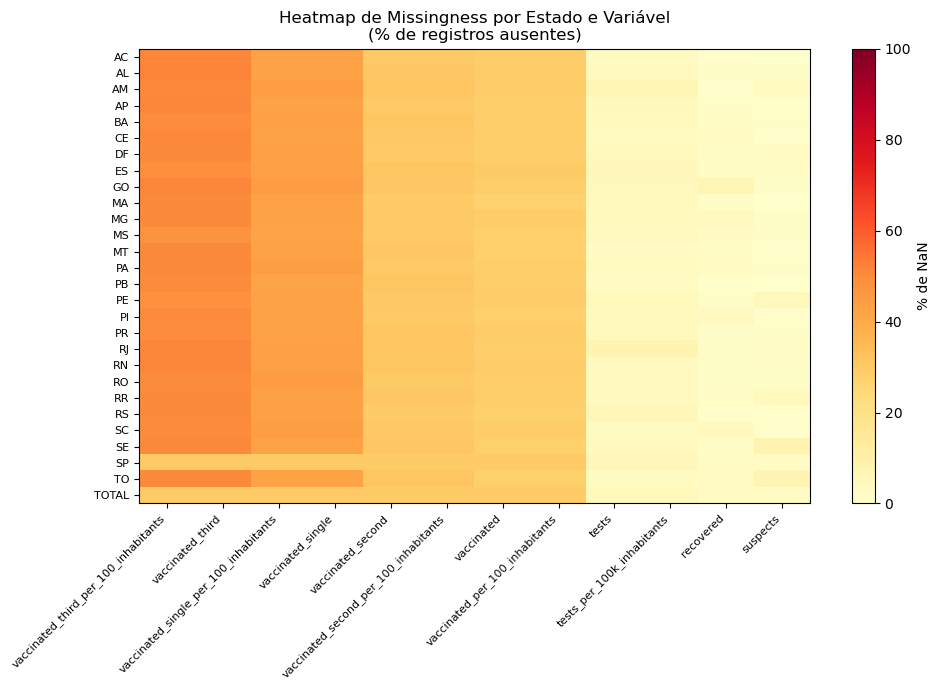


Interpretação:
- Colunas uniformemente laranja/vermelho → ausência ESTRUTURAL (justifica fillna(0))
- Colunas com padrão irregular por estado → ausência SELETIVA (risco de viés)


In [100]:
# Heatmap de missingness por estado

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

colunas_com_nan = missingness.index.tolist()

# Proporção de NaN por estado para cada coluna com missing
missing_by_state = (
    sub[["state"] + colunas_com_nan]
    .groupby("state")
    .apply(lambda g: g[colunas_com_nan].isnull().mean() * 100)
)

fig, ax = plt.subplots(figsize=(max(10, len(colunas_com_nan) * 0.7), 7))

im = ax.imshow(missing_by_state.values, aspect="auto", cmap="YlOrRd", vmin=0, vmax=100)

ax.set_xticks(range(len(colunas_com_nan)))
ax.set_xticklabels(colunas_com_nan, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(missing_by_state.index)))
ax.set_yticklabels(missing_by_state.index, fontsize=8)

plt.colorbar(im, ax=ax, label="% de NaN")
ax.set_title("Heatmap de Missingness por Estado e Variável\n(% de registros ausentes)", fontsize=12)
plt.tight_layout()
plt.show()

print("\nInterpretação:")
print("- Colunas uniformemente laranja/vermelho → ausência ESTRUTURAL (justifica fillna(0))")
print("- Colunas com padrão irregular por estado → ausência SELETIVA (risco de viés)")

In [101]:
sub.fillna(0, inplace=True)
print("\n✓ fillna(0) aplicado. NaN restantes:", sub.isnull().sum().sum())


✓ fillna(0) aplicado. NaN restantes: 0


### Criação de Variáveis derivadas

In [102]:
sub = region(sub)

Sucesso: Coluna de regiões criada


In [103]:
sub = aplicar_medias_moveis(sub)

Sucesso: Médias móveis aplicadas para as colunas ['newCases', 'newDeaths'] nas janelas [7, 15, 30].


In [104]:
sub['taxa_letalidade'] = sub['deaths_by_totalCases'] * 100

In [105]:
sub['onda'] = sub['date'].apply(classificar_onda)

In [106]:
sub = defasagem(sub, colunas_alvo=['newCases'], lags=[7, 14, 21])
sub = defasagem(sub, colunas_alvo=['newDeaths'], lags=[7, 14, 21])

Sucesso: Lags de [7, 14, 21] dias aplicados para as colunas ['newCases'].
Sucesso: Lags de [7, 14, 21] dias aplicados para as colunas ['newDeaths'].


In [107]:
sub.shape

(9293, 40)

In [108]:
sub.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9293 entries, 0 to 9292
Data columns (total 40 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   date                                   9293 non-null   datetime64[ns]
 1   state                                  9293 non-null   object        
 2   newDeaths                              9293 non-null   int64         
 3   deaths                                 9293 non-null   int64         
 4   newCases                               9293 non-null   int64         
 5   totalCases                             9293 non-null   int64         
 6   deathsMS                               9293 non-null   int64         
 7   totalCasesMS                           9293 non-null   int64         
 8   deaths_per_100k_inhabitants            9293 non-null   float64       
 9   totalCases_per_100k_inhabitants        9293 non-null   float64 

In [109]:
data = region(data)
data['region'].value_counts(normalize=True)

Sucesso: Coluna de regiões criada


region
Nordeste        0.321023
Norte           0.248719
Sudeste         0.143992
Centro-Oeste    0.142760
Sul             0.107256
Nacional        0.036249
Name: proportion, dtype: float64

In [110]:
sub['region'].value_counts(normalize=True)

region
Nordeste        0.320994
Norte           0.248682
Sudeste         0.143979
Centro-Oeste    0.142796
Sul             0.107285
Nacional        0.036264
Name: proportion, dtype: float64

In [111]:
print(data['date'].min())
print(sub['date'].min())

2020-02-25 00:00:00
2020-02-27 00:00:00


In [112]:
print(data['date'].max())
print(sub['date'].max())

2023-03-18 00:00:00
2023-03-18 00:00:00


In [113]:
# Frequência de notificação por estado

freq_estado = (
    sub_estados
    .groupby("state")
    .agg(
        primeira_data=("date", "min"),
        ultima_data=("date", "max"),
        n_relatorios=("date", "count"),
        dias_unicos=("date", "nunique")
    )
    .reset_index()
)

# Período coberto por cada estado
freq_estado["dias_periodo"] = (
    freq_estado["ultima_data"] - freq_estado["primeira_data"]
).dt.days + 1

# % dos dias com notificação
freq_estado["pct_dias_reportados"] = (
    100 * freq_estado["dias_unicos"] / freq_estado["dias_periodo"]
)

# Média de relatórios por mês
freq_estado["relatorios_mes"] = (
    freq_estado["dias_unicos"] /
    (freq_estado["dias_periodo"] / 30.44)
)

freq_estado = freq_estado.sort_values(
    "pct_dias_reportados",
    ascending=False
)

display(
    freq_estado[
        [
            "state",
            "dias_unicos",
            "dias_periodo",
            "pct_dias_reportados",
            "relatorios_mes"
        ]
    ].round(2)
)

,state,dias_unicos,dias_periodo,pct_dias_reportados,relatorios_mes
11,MS,331,1088,30.42,9.26
25,SP,337,1110,30.36,9.24
13,PA,330,1087,30.36,9.24
5,CE,331,1091,30.34,9.24
6,DF,334,1101,30.34,9.23
14,PB,330,1089,30.30,9.22
2,AM,332,1096,30.29,9.22
3,AP,330,1090,30.28,9.22
24,SE,331,1094,30.26,9.21
20,RO,330,1091,30.25,9.21


In [114]:
# Maiores lacunas entre notificações

gaps = (
    sub_estados
    .sort_values(["state", "date"])
    .drop_duplicates(["state", "date"])
)

gaps["dias_desde_anterior"] = (
    gaps
    .groupby("state")["date"]
    .diff()
    .dt.days
)

maiores_gaps = (
    gaps
    .groupby("state")
    .agg(
        maior_gap=("dias_desde_anterior", "max"),
        media_gap=("dias_desde_anterior", "mean")
    )
    .reset_index()
    .sort_values("maior_gap", ascending=False)
)

display(maiores_gaps)

,state,maior_gap,media_gap
12,MT,23.0,3.322188
15,PE,22.0,3.320242
16,PI,21.0,3.319149
11,MS,19.0,3.293939
3,AP,19.0,3.310030
8,GO,19.0,3.323263
25,SP,19.0,3.300595
23,SC,18.0,3.320242
24,SE,18.0,3.312121
4,BA,18.0,3.315315


In [115]:
gaps_maiores_15 = gaps[gaps["dias_desde_anterior"] > 15]

display(
    gaps_maiores_15[
        ["state", "date", "dias_desde_anterior"]
    ].sort_values(
        ["dias_desde_anterior", "state"],
        ascending=[False, True]
    )
)

,state,date,dias_desde_anterior
4247,MT,2022-08-13,23.0
5130,PE,2021-08-20,22.0
5441,PI,2021-06-17,21.0
1101,AP,2021-03-17,19.0
2794,GO,2021-06-14,19.0
3769,MS,2021-04-20,19.0
8581,SP,2022-11-04,19.0
1626,BA,2022-12-05,18.0
7855,SC,2022-04-26,18.0
8060,SE,2021-02-21,18.0


In [116]:
sub_estados["month"] = sub_estados["date"].dt.to_period("M")

reports_month_state = (
    sub_estados
    .groupby(["state", "month"])
    .size()
    .reset_index(name="reports")
)

media_mensal = (
    reports_month_state
    .groupby("state")["reports"]
    .mean()
    .reset_index(name="media_reports_mes")
    .sort_values("media_reports_mes", ascending=False)
)

display(media_mensal)

,state,media_reports_mes
25,SP,9.108108
6,DF,9.027027
7,ES,9.027027
18,RJ,9.027027
4,BA,9.027027
1,AL,9.000000
10,MG,9.000000
22,RS,9.000000
15,PE,8.972973
8,GO,8.972973


In [117]:
import plotly.express as px

reports_estado = (
    sub_estados
    .groupby("state")
    .size()
    .reset_index(name="n_reports")
    .sort_values("n_reports", ascending=False)
)

fig = px.bar(
    reports_estado,
    x="state",
    y="n_reports",
    text="n_reports",
    title="Quantidade de reports por estado",
    labels={
        "state": "Estado",
        "n_reports": "Número de reports"
    }
)

fig.update_traces(textposition="outside")
fig.update_layout(
    xaxis_title="Estado",
    yaxis_title="Número de reports",
    showlegend=False
)

fig.show()

In [118]:
# Checa valores negativos em TODAS as colunas numéricas

colunas_numericas = sub.select_dtypes(include="number").columns.tolist()

# Colunas que por definição nunca podem ser negativas
nao_podem_ser_negativos = [
    "newDeaths", "deaths", "newCases", "totalCases",
    "deathsMS", "totalCasesMS",
    "deaths_per_100k_inhabitants", "totalCases_per_100k_inhabitants",
    "deaths_by_totalCases",
    "recovered", "suspects", "tests", "tests_per_100k_inhabitants",
    "vaccinated", "vaccinated_per_100_inhabitants",
    "vaccinated_second", "vaccinated_second_per_100_inhabitants",
    "vaccinated_single", "vaccinated_single_per_100_inhabitants",
    "vaccinated_third", "vaccinated_third_per_100_inhabitants",
    "newCases_mm7", "newCases_mm15", "newCases_mm30",
    "newDeaths_mm7", "newDeaths_mm15", "newDeaths_mm30",
]

print(f"{'Coluna':<45} {'N negativos':>12} {'Min':>10} {'Estados afetados'}")
print("─" * 100)

negativos_encontrados = {}

for col in nao_podem_ser_negativos:
    if col not in sub.columns:
        continue
    mask = sub[col] < 0
    n = mask.sum()
    if n > 0:
        estados = sorted(sub.loc[mask, "state"].unique().tolist())
        min_val  = sub.loc[mask, col].min()
        negativos_encontrados[col] = sub[mask][["date", "state", col, "deaths", "newDeaths", "onda"]]
        print(f"{col:<45} {n:>12} {min_val:>10.1f}  {estados}")

if not negativos_encontrados:
    print("Nenhum valor negativo encontrado fora de newDeaths.")

Coluna                                         N negativos        Min Estados afetados
────────────────────────────────────────────────────────────────────────────────────────────────────
newDeaths                                               25      -43.0  ['CE', 'ES', 'GO', 'MG', 'MS', 'MT', 'PA', 'PR', 'RO', 'RS']
newCases                                                14    -4174.0  ['CE', 'ES', 'GO', 'RN', 'RO', 'SC', 'TOTAL']
newCases_mm7                                             6      -26.1  ['CE']
newDeaths_mm7                                            3       -0.1  ['RO']


In [119]:
# Para cada coluna com negativos: mostra os registros completos 

for col, df_neg in negativos_encontrados.items():
    if col == "newDeaths":
        continue  # já analisamos
    print(f"\n{'═'*70}")
    print(f"Coluna: {col}  |  {len(df_neg)} registros negativos")
    print(f"{'═'*70}")
    print(df_neg.sort_values(col).to_string())


══════════════════════════════════════════════════════════════════════
Coluna: newCases  |  14 registros negativos
══════════════════════════════════════════════════════════════════════
           date  state  newCases  deaths  newDeaths             onda
9284 2023-02-14  TOTAL     -4174  697848         86       5_pos_pico
6777 2021-07-07     RO      -850    6234          8          2_gamma
6346 2020-08-12     RN      -649    2042         17  1_pre_vacinacao
1826 2021-09-21     CE      -531   24158          1          3_delta
2956 2022-11-29     GO      -356   27628          5       5_pos_pico
6345 2020-08-11     RN      -211    2025          6  1_pre_vacinacao
1988 2023-03-10     CE      -155   28157          0       5_pos_pico
7737 2021-03-10     SC      -110    8277        107          2_gamma
2855 2021-12-25     GO       -72   24673         20        4_omicron
2611 2022-10-24     ES       -69   14827          0       5_pos_pico
2602 2022-09-17     ES       -18   14812          0   

In [120]:
print(f"Total de colunas com valores negativos: {len(negativos_encontrados)}")
print()

for col, df_neg in negativos_encontrados.items():
    estados  = sorted(df_neg["state"].unique().tolist())
    
    # Extrai o valor mínimo de forma segura independente do tipo retornado
    min_series = sub.loc[sub[col] < 0, col]
    min_val    = min_series.values.min()  # numpy scalar — nunca ambíguo
    n          = int((sub[col] < 0).sum())
    
    print(f"  • {col}: {n} registros | min={min_val:.0f} | estados: {estados}")

Total de colunas com valores negativos: 4

  • newDeaths: 25 registros | min=-43 | estados: ['CE', 'ES', 'GO', 'MG', 'MS', 'MT', 'PA', 'PR', 'RO', 'RS']
  • newCases: 14 registros | min=-4174 | estados: ['CE', 'ES', 'GO', 'RN', 'RO', 'SC', 'TOTAL']
  • newCases_mm7: 6 registros | min=-26 | estados: ['CE']
  • newDeaths_mm7: 3 registros | min=-0 | estados: ['RO']


In [121]:
colunas_clip = ["newDeaths", "newCases"]

antes = {col: (sub[col] < 0).sum() for col in colunas_clip}

for col in colunas_clip:
    sub[col] = sub[col].clip(lower=0)

depois = {col: (sub[col] < 0).sum() for col in colunas_clip}

print("Resultado do clip(lower=0):")
for col in colunas_clip:
    print(f"  {col}: {antes[col]} negativos → {depois[col]} negativos")

Resultado do clip(lower=0):
  newDeaths: 25 negativos → 0 negativos
  newCases: 14 negativos → 0 negativos


In [122]:
sub = aplicar_medias_moveis(sub)

Sucesso: Médias móveis aplicadas para as colunas ['newCases', 'newDeaths'] nas janelas [7, 15, 30].


In [123]:
# Criação definitiva de sub_estados 

sub_estados = sub[sub['state'] != 'TOTAL'].copy()

print(f"sub_estados recriado: {sub_estados.shape[0]} linhas, {sub_estados.shape[1]} colunas")
print(f"Colunas presentes: 'onda' -> {'onda' in sub_estados.columns} | "
      f"'newCases_lag7' -> {'newCases_lag7' in sub_estados.columns} | "
      f"newDeaths min -> {sub_estados['newDeaths'].min()}")

sub_estados recriado: 8956 linhas, 40 colunas
Colunas presentes: 'onda' -> True | 'newCases_lag7' -> True | newDeaths min -> 0


# Exploratória

In [124]:
variaveis_foco = [
    'newDeaths',
    'deaths',
    'newCases',
    'totalCases',
    'deathsMS',
    'totalCasesMS',
    'deaths_per_100k_inhabitants',
    'totalCases_per_100k_inhabitants',
    'deaths_by_totalCases',
    'recovered',
    'suspects',
    'tests',
    'tests_per_100k_inhabitants',
    'vaccinated',
    'vaccinated_per_100_inhabitants',
    'vaccinated_second',
    'vaccinated_second_per_100_inhabitants',
    'vaccinated_single',
    'vaccinated_single_per_100_inhabitants',
    'vaccinated_third',
    'vaccinated_third_per_100_inhabitants',
    'newCases_mm7',
    'newCases_mm15',
    'newCases_mm30',
    'newDeaths_mm7',
    'newDeaths_mm15',
    'newDeaths_mm30'
]

sub_estados[variaveis_foco].describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
newDeaths,8956.0,23.825,64.353,0.000,0.000,5.000,20.000,1.282000e+03
deaths,8956.0,16661.815,27179.090,0.000,2462.500,7992.500,18609.250,1.790390e+05
newCases,8956.0,1270.588,2753.549,0.000,73.000,411.000,1280.000,6.922300e+04
totalCases,8956.0,724636.777,1007811.070,1.000,142619.750,366387.000,855363.500,6.469442e+06
deathsMS,8956.0,16658.708,27179.603,0.000,2461.000,7990.000,18608.750,1.790390e+05
totalCasesMS,8956.0,724477.549,1007850.345,0.000,142530.000,366251.000,854992.000,6.469442e+06
deaths_per_100k_inhabitants,8956.0,207.798,126.720,0.000,92.161,217.658,311.798,4.451330e+02
totalCases_per_100k_inhabitants,8956.0,10687.456,7850.614,0.005,3925.336,9980.215,15226.586,3.293631e+04
deaths_by_totalCases,8956.0,0.024,0.013,0.000,0.016,0.021,0.026,2.110000e-01
recovered,8956.0,612900.912,840638.606,0.000,119470.000,319842.000,699477.000,4.850000e+06


## 1 — Série Temporal: Casos e Óbitos por Estado

In [42]:
def plot_serie_temporal_casos_obitos(df, estados=None, altura=650):
    """
    Série temporal (linhas) de novos casos e novos óbitos por estado,
    usando médias móveis de 7 dias para suavizar ruídos.

    Parâmetros
    ----------
    df      : DataFrame com 'state', 'date', 'newCases_mm7', 'newDeaths_mm7'
    estados : lista de siglas; se None, usa os 5 maiores em casos totais
    altura  : altura do gráfico em pixels
    """
    if estados is None:
        estados = (
            df.groupby('state')['totalCases'].max()
            .nlargest(5).index.tolist()
        )

    df_plot = df[df['state'].isin(estados)].sort_values('date')
    palette = px.colors.qualitative.Plotly

    fig = make_subplots(
        rows=2, cols=1,
        shared_xaxes=True,
        subplot_titles=(
            '<b>Novos Casos</b> — Média Móvel 7 dias',
            '<b>Novos Óbitos</b> — Média Móvel 7 dias'
        ),
        vertical_spacing=0.10
    )

    for i, estado in enumerate(estados):
        df_e = df_plot[df_plot['state'] == estado]
        cor  = palette[i % len(palette)]

        fig.add_trace(
            go.Scatter(
                x=df_e['date'], y=df_e['newCases_mm7'],
                name=estado, mode='lines',
                line=dict(color=cor, width=2),
                legendgroup=estado,
            ),
            row=1, col=1
        )
        fig.add_trace(
            go.Scatter(
                x=df_e['date'], y=df_e['newDeaths_mm7'],
                name=estado, mode='lines',
                line=dict(color=cor, width=2, dash='dot'),
                legendgroup=estado,
                showlegend=False,
            ),
            row=2, col=1
        )

    fig.update_layout(
        title='<b>Série Temporal — Novos Casos e Óbitos por Estado</b>',
        title_font_size=18,
        hovermode='x unified',
        template='plotly_white',
        legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='center', x=0.5),
        height=altura,
    )
    fig.update_xaxes(title_text='Data', row=2, col=1)
    fig.update_yaxes(title_text='Novos Casos (MM7)',  row=1, col=1)
    fig.update_yaxes(title_text='Novos Óbitos (MM7)', row=2, col=1)

    datas_vacinacao = [
        ("1ª Onda", "2021-01-16", "green"),
        ("2ª Onda", "2021-07-01", "orange"),
        ("3ª Onda", "2021-09-15", "red"),
    ]

    for nome, data, cor in datas_vacinacao:
        fig.add_vline(
            x=data,
            line_width=2,
            line_dash="dash",
            line_color=cor
        )

        fig.add_annotation(
            x=data,
            y=0.98,
            yref="paper",
            text=f"<b>{nome}</b>",
            showarrow=False,
            xanchor="left",
            bgcolor="white",
            bordercolor=cor,
            borderwidth=1,
            font=dict(color=cor, size=11)
        )

    ondas = [
        ("Pré-vacinação", "2020-02-26", "black"),
        ("Gamma",         "2021-01-17", "purple"),
        ("Delta",         "2021-08-15", "blue"),
        ("Ômicron",       "2021-12-15", "red"),
        ("Pós-pico",      "2022-07-01", "green"),
    ]

    for nome, data, cor in ondas:
            fig.add_vline(
                x=data,
                line_color=cor,
                line_dash="dot",
                line_width=2
            )

            fig.add_annotation(
                x=data,
                y=1.06,
                yref="paper",
                text=f"<b>{nome}</b>",
                showarrow=False,
                xanchor="left",
                font=dict(size=10, color=cor)
            )

    fig.show()


plot_serie_temporal_casos_obitos(sub_estados)

## 2 — Série Temporal: Vacinação por Estado

In [43]:
def plot_serie_temporal_vacinacao(df, estados=None, altura=550):
    """
    Série temporal do avanço da vacinação (% da população com 1ª dose)
    por estado, sobreposta à curva de óbitos (MM7) para evidenciar correlação.

    Usa a coluna já existente 'vaccinated_per_100_inhabitants' (porcentagem).

    Parâmetros
    ----------
    df      : DataFrame com 'state', 'date', 'vaccinated_per_100_inhabitants', 'newDeaths_mm7'
    estados : lista de siglas; se None, usa os 5 com maior cobertura vacinal final
    altura  : altura do gráfico em pixels
    """
    if estados is None:
        estados = (
            df.groupby('state')['vaccinated_per_100_inhabitants'].max()
            .nlargest(5).index.tolist()
        )

    df_plot  = df[df['state'].isin(estados)].sort_values('date')
    palette  = px.colors.qualitative.Safe

    fig = make_subplots(specs=[[{"secondary_y": True}]])

    for i, estado in enumerate(estados):
        df_e = df_plot[df_plot['state'] == estado]
        cor  = palette[i % len(palette)]

        # Vacinação — 1ª dose (%) — eixo primário
        fig.add_trace(
            go.Scatter(
                x=df_e['date'], y=df_e['vaccinated_per_100_inhabitants'],
                name=f'{estado} — 1ª Dose (%)',
                mode='lines',
                line=dict(color=cor, width=2),
                legendgroup=estado,
            ),
            secondary_y=False
        )
        # Óbitos MM7 — eixo secundário, tracejado
        fig.add_trace(
            go.Scatter(
                x=df_e['date'], y=df_e['newDeaths_mm7'],
                name=f'{estado} — Óbitos',
                mode='lines',
                line=dict(color=cor, width=1.5, dash='dash'),
                legendgroup=estado,
                showlegend=False,
                opacity=0.6,
            ),
            secondary_y=True
        )

    fig.update_layout(
        title='<b>Série Temporal — Vacinação (1ª Dose %) e Óbitos por Estado</b>',
        title_font_size=18,
        hovermode='x unified',
        template='plotly_white',
        legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='center', x=0.5),
        height=altura,
    )
    fig.update_xaxes(title_text='Data')
    fig.update_yaxes(title_text='<b>1ª Dose (% pop.)</b>',    color='SteelBlue', secondary_y=False)
    fig.update_yaxes(title_text='<b>Novos Óbitos (MM7)</b>',  color='Crimson',   secondary_y=True)
    fig.show()


plot_serie_temporal_vacinacao(sub_estados)

In [125]:
# ── Teste 4: Vacinação x Óbitos, restrito a um único estado (SP), sem lag ──────
# Usa a amostra de 30% (sub), mas filtrando apenas SP, eliminando o efeito de
# diluição da agregação nacional. Lags são desconsiderados pois o intervalo
# médio entre reports (~9 dias) é maior que os lags testados anteriormente
# (7 dias), tornando defasagens curtas pouco confiáveis nesta granularidade.

agg_sp = (
    sub[sub["state"] == "SP"]
    .sort_values("date")
    .set_index("date")[["vaccinated_per_100_inhabitants", "newDeaths_mm7"]]
    .rename(columns={"vaccinated_per_100_inhabitants": "vac_sp", "newDeaths_mm7": "obitos_sp"})
)

print(f"Total de registros (SP, amostra 30%): {len(agg_sp)}")
print(f"Período: {agg_sp.index.min().date()} a {agg_sp.index.max().date()}")

# Intervalo médio entre reports consecutivos, para justificar a decisão de não usar lag
intervalos = agg_sp.index.to_series().diff().dt.days.dropna()
print(f"Intervalo médio entre reports em SP: {intervalos.mean():.1f} dias")
print(f"Intervalo mediano: {intervalos.median():.1f} dias")

Total de registros (SP, amostra 30%): 337
Período: 2020-03-04 a 2023-03-18
Intervalo médio entre reports em SP: 3.3 dias
Intervalo mediano: 2.0 dias


In [126]:
# ── Teste 1 (replicado para SP): correlação ingênua + correlação com o tempo ──

r_ingenua_sp, p_ingenua_sp = pearsonr(agg_sp["vac_sp"], agg_sp["obitos_sp"])

agg_sp["tempo_numerico"] = range(len(agg_sp))
r_vac_tempo_sp, p_vac_tempo_sp = pearsonr(agg_sp["vac_sp"], agg_sp["tempo_numerico"])
r_obitos_tempo_sp, p_obitos_tempo_sp = pearsonr(agg_sp["obitos_sp"], agg_sp["tempo_numerico"])

print("=== Teste 1 (SP): Correlação ingênua e tendência temporal ===")
print(f"Correlação ingênua vacinação x óbitos (SP): r={r_ingenua_sp:+.3f}, p={p_ingenua_sp:.4f}")
print(f"Correlação vacinação x tempo (SP):           r={r_vac_tempo_sp:+.3f}, p={p_vac_tempo_sp:.4f}")
print(f"Correlação óbitos x tempo (SP):               r={r_obitos_tempo_sp:+.3f}, p={p_obitos_tempo_sp:.4f}")

=== Teste 1 (SP): Correlação ingênua e tendência temporal ===
Correlação ingênua vacinação x óbitos (SP): r=-0.390, p=0.0000
Correlação vacinação x tempo (SP):           r=+0.925, p=0.0000
Correlação óbitos x tempo (SP):               r=-0.329, p=0.0000


In [127]:
# ── Teste 2 (replicado para SP): diferenciação, SEM nenhum lag ────────────────
# Remove a tendência comum, testando a relação entre a VARIAÇÃO de vacinação
# e a VARIAÇÃO de óbitos no mesmo período (lag=0), conforme solicitado.

agg_sp_diff = agg_sp[["vac_sp", "obitos_sp"]].diff().dropna()

r_diff_sp, p_diff_sp = pearsonr(agg_sp_diff["vac_sp"], agg_sp_diff["obitos_sp"])

print("=== Teste 2 (SP): Diferenciação (sem lag) ===")
print(f"Correlação em níveis (SP):          r={r_ingenua_sp:+.3f}")
print(f"Correlação após diferenciação (SP): r={r_diff_sp:+.3f}, p={p_diff_sp:.4f}")

=== Teste 2 (SP): Diferenciação (sem lag) ===
Correlação em níveis (SP):          r=-0.390
Correlação após diferenciação (SP): r=+0.017, p=0.7601


In [128]:
# ── Teste 3 (replicado para SP): decomposição por onda, SEM lag ───────────────
# Mesma lógica usada na análise nacional, mas agora isolando SP — eliminando
# tanto a diluição nacional quanto a defasagem de lag, que não é confiável
# dado o intervalo médio de ~9 dias entre reports.

sp_com_onda = sub[sub["state"] == "SP"][["date", "vaccinated_per_100_inhabitants", "newDeaths_mm7", "onda"]].copy()

correlacoes_onda_sp = []
for onda, grupo in sp_com_onda.groupby("onda"):
    if grupo["vaccinated_per_100_inhabitants"].std() == 0 or len(grupo) < 5:
        continue
    r, p = pearsonr(grupo["vaccinated_per_100_inhabitants"], grupo["newDeaths_mm7"])
    correlacoes_onda_sp.append({"onda": onda, "r": r, "p_valor": p, "n": len(grupo)})

df_onda_sp = pd.DataFrame(correlacoes_onda_sp)
print("=== Teste 3 (SP): Correlação por onda epidemiológica ===")
print(df_onda_sp.to_string(index=False))

=== Teste 3 (SP): Correlação por onda epidemiológica ===
      onda         r      p_valor  n
   2_gamma -0.002984 9.813315e-01 64
   3_delta -0.967077 3.465513e-21 35
 4_omicron  0.062232 6.366685e-01 60
5_pos_pico -0.487192 5.281894e-06 79


In [129]:
# ── Comparação final: SP isolado vs. Nacional agregado ────────────────────────

print("=== Comparação: SP vs. Nacional (todos sem lag) ===\n")
print(f"{'Métrica':<40} {'Nacional':>12} {'SP':>12}")
print("─" * 66)
print(f"{'Correlação ingênua (níveis)':<40} {-0.427:>12.3f} {r_ingenua_sp:>12.3f}")
print(f"{'Correlação vac x tempo':<40} {0.937:>12.3f} {r_vac_tempo_sp:>12.3f}")
print(f"{'Correlação óbitos x tempo':<40} {-0.341:>12.3f} {r_obitos_tempo_sp:>12.3f}")
print(f"{'Correlação após diferenciação':<40} {0.186:>12.3f} {r_diff_sp:>12.3f}")

=== Comparação: SP vs. Nacional (todos sem lag) ===

Métrica                                      Nacional           SP
──────────────────────────────────────────────────────────────────
Correlação ingênua (níveis)                    -0.427       -0.390
Correlação vac x tempo                          0.937        0.925
Correlação óbitos x tempo                      -0.341       -0.329
Correlação após diferenciação                   0.186        0.017


In [130]:
# ── Teste de controle: a Delta em SP (r=-0,967) é real ou artefato? ───────────
# Mesma lógica aplicada à Delta nacional: verifica se ambas as séries têm
# tendência forte dentro da própria janela Delta, e se a correlação resiste
# à diferenciação (remoção dessa tendência).

delta_sp = sp_com_onda[sp_com_onda["onda"] == "3_delta"].sort_values("date").set_index("date")
delta_sp = delta_sp[["vaccinated_per_100_inhabitants", "newDeaths_mm7"]].rename(
    columns={"vaccinated_per_100_inhabitants": "vac_sp", "newDeaths_mm7": "obitos_sp"}
)

print(f"Registros na onda Delta (SP): {len(delta_sp)}")
print(f"Período: {delta_sp.index.min().date()} a {delta_sp.index.max().date()}")

delta_sp["tempo_numerico"] = range(len(delta_sp))

# Tendência de cada série dentro da Delta
r_vac_tempo_delta, p_vac_tempo_delta = pearsonr(delta_sp["vac_sp"], delta_sp["tempo_numerico"])
r_obitos_tempo_delta, p_obitos_tempo_delta = pearsonr(delta_sp["obitos_sp"], delta_sp["tempo_numerico"])

print("\n=== Tendência dentro da onda Delta (SP) ===")
print(f"Vacinação x tempo (Delta, SP):  r={r_vac_tempo_delta:+.3f}, p={p_vac_tempo_delta:.4f}")
print(f"Óbitos x tempo (Delta, SP):     r={r_obitos_tempo_delta:+.3f}, p={p_obitos_tempo_delta:.4f}")
print(f"Vacinação x óbitos (níveis, já obtido): r=-0.967")

Registros na onda Delta (SP): 35
Período: 2021-08-26 a 2021-12-14

=== Tendência dentro da onda Delta (SP) ===
Vacinação x tempo (Delta, SP):  r=+0.907, p=0.0000
Óbitos x tempo (Delta, SP):     r=-0.905, p=0.0000
Vacinação x óbitos (níveis, já obtido): r=-0.967


In [131]:
# ── Diferenciação dentro da Delta (SP) ─────────────────────────────────────────

delta_sp_diff = delta_sp[["vac_sp", "obitos_sp"]].diff().dropna()

r_diff_delta_sp, p_diff_delta_sp = pearsonr(delta_sp_diff["vac_sp"], delta_sp_diff["obitos_sp"])

print("=== Diferenciação dentro da Delta (SP) ===")
print(f"Correlação em níveis (Delta, SP):          r=-0.967")
print(f"Correlação após diferenciação (Delta, SP): r={r_diff_delta_sp:+.3f}, p={p_diff_delta_sp:.4f}")
print()
print("Se a correlação cair MUITO ou inverter de sinal, confirma que o r=-0,967")
print("é também tendência local espúria, replicando o padrão já visto na Delta nacional.")

=== Diferenciação dentro da Delta (SP) ===
Correlação em níveis (Delta, SP):          r=-0.967
Correlação após diferenciação (Delta, SP): r=-0.004, p=0.9840

Se a correlação cair MUITO ou inverter de sinal, confirma que o r=-0,967
é também tendência local espúria, replicando o padrão já visto na Delta nacional.


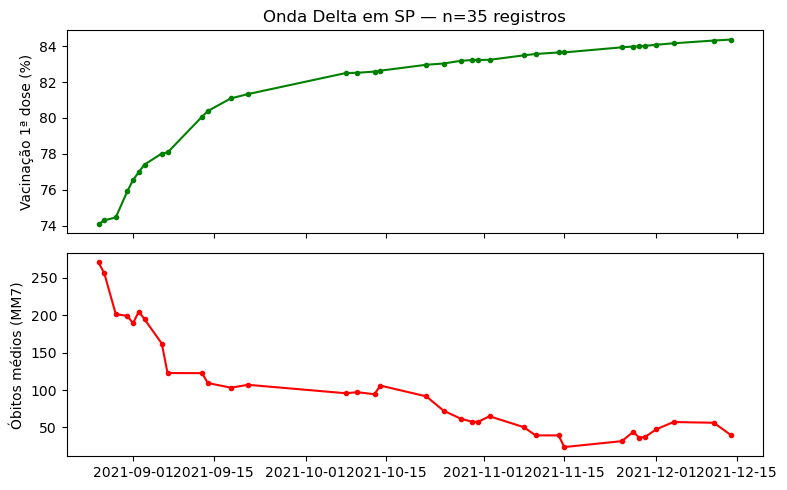

In [133]:
# ── Visualização: vacinação e óbitos dentro da Delta em SP ────────────────────

fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
axes[0].plot(delta_sp.index, delta_sp["vac_sp"], color="green", marker="o", markersize=3)
axes[0].set_ylabel("Vacinação 1ª dose (%)")
axes[0].set_title(f"Onda Delta em SP — n={len(delta_sp)} registros")

axes[1].plot(delta_sp.index, delta_sp["obitos_sp"], color="red", marker="o", markersize=3)
axes[1].set_ylabel("Óbitos médios (MM7)")
plt.tight_layout()
plt.show()

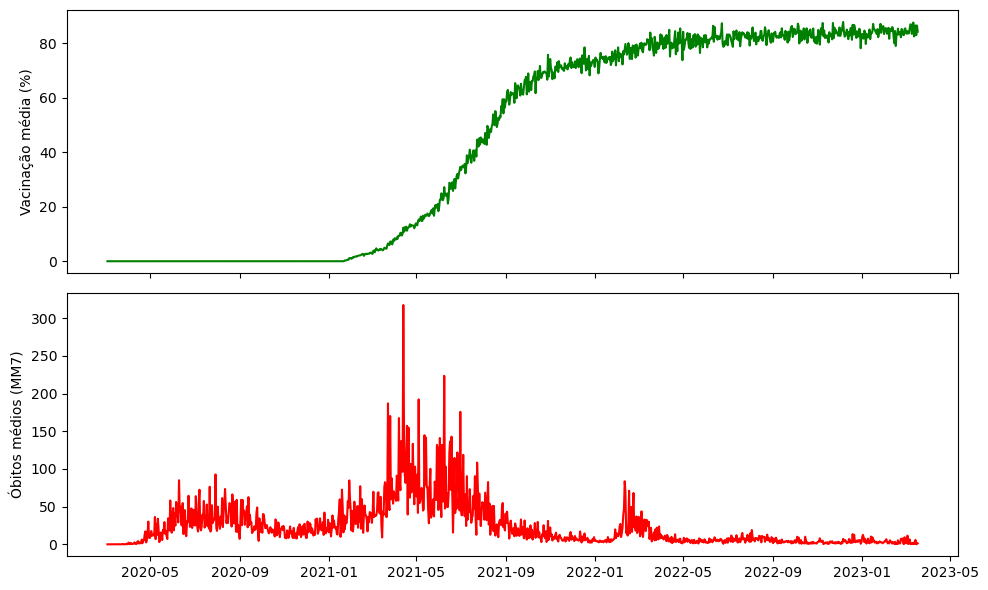

Correlação ingênua vacinação x óbitos: -0.427
Correlação vacinação x tempo:         0.937
Correlação óbitos x tempo:             -0.341

Se ambas as correlações com o tempo forem fortes (|r|>0.5),
a correlação vacinação-óbitos é suspeita de ser espúria.


In [ ]:
# ── Passo 1: Evidenciar a confusão temporal ────────────────────────────────────

import matplotlib.pyplot as plt

agg = (
    sub[sub["state"] != "TOTAL"]
    .groupby("date")
    .agg(
        vac_media=("vaccinated_per_100_inhabitants", "mean"),
        obitos_media=("newDeaths_mm7", "mean"),
    )
    .reset_index()
)

agg["tempo_numerico"] = (agg["date"] - agg["date"].min()).dt.days

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(agg["date"], agg["vac_media"], color="green")
axes[0].set_ylabel("Vacinação média (%)")

axes[1].plot(agg["date"], agg["obitos_media"], color="red")
axes[1].set_ylabel("Óbitos médios (MM7)")
plt.tight_layout()
plt.show()

# Correlação ingênua (a que está no relatório, problemática)
corr_ingenua = agg[["vac_media", "obitos_media"]].corr().iloc[0, 1]
print(f"Correlação ingênua vacinação x óbitos: {corr_ingenua:.3f}")

# Correlação de cada série com o TEMPO em si
corr_vac_tempo = agg[["vac_media", "tempo_numerico"]].corr().iloc[0, 1]
corr_obitos_tempo = agg[["obitos_media", "tempo_numerico"]].corr().iloc[0, 1]
print(f"Correlação vacinação x tempo:         {corr_vac_tempo:.3f}")
print(f"Correlação óbitos x tempo:             {corr_obitos_tempo:.3f}")
print()
print("Se ambas as correlações com o tempo forem fortes (|r|>0.5),")
print("a correlação vacinação-óbitos é suspeita de ser espúria.")

In [ ]:
# ── Passo 2: Correlação com diferenciação (remove a tendência) ────────────────

agg_diff = agg.set_index("date")[["vac_media", "obitos_media"]].diff().dropna()

corr_diff = agg_diff.corr().iloc[0, 1]
print(f"Correlação ingênua (níveis):     {corr_ingenua:.3f}")
print(f"Correlação após diferenciação:   {corr_diff:.3f}")
print()
print("Se a correlação cair MUITO (ex: de -0.85 para -0.20) ao diferenciar,")
print("isso confirma que a correlação original era majoritariamente espúria,")
print("causada pela tendência temporal compartilhada, não por relação direta.")

Correlação ingênua (níveis):     -0.427
Correlação após diferenciação:   0.186

Se a correlação cair MUITO (ex: de -0.85 para -0.20) ao diferenciar,
isso confirma que a correlação original era majoritariamente espúria,
causada pela tendência temporal compartilhada, não por relação direta.


In [ ]:
# ── Teste 3 (revisado): lags farmacologicamente ancorados ─────────────────────

from scipy.stats import pearsonr

agg2 = (
    sub[sub["state"] != "TOTAL"]
    .groupby("date")
    .agg(
        vac1_media=("vaccinated_per_100_inhabitants", "mean"),
        vac2_media=("vaccinated_second_per_100_inhabitants", "mean"),
        obitos_media=("newDeaths_mm7", "mean"),
    )
    .reset_index()
    .set_index("date")
)

agg2_diff = agg2.diff().dropna()

# Lags farmacologicamente justificados
lags_1a_dose = [14, 21]          # início de imunidade parcial
lags_2a_dose = [14, 21, 28, 35]  # imunidade robusta + pico de eficácia

print("=== Lag para 1ª dose (vaccinated) ===")
resultados_1a = []
for lag in lags_1a_dose:
    vac_lag = agg2_diff["vac1_media"].shift(lag)
    valid = vac_lag.notna() & agg2_diff["obitos_media"].notna()
    r, p = pearsonr(vac_lag[valid], agg2_diff["obitos_media"][valid])
    resultados_1a.append({"lag_dias": lag, "correlacao": r, "p_valor": p, "n": valid.sum()})
    print(f"  lag={lag:2d}d | r={r:+.3f} | p={p:.4f} | n={valid.sum()}")

print("\n=== Lag para 2ª dose (vaccinated_second) ===")
resultados_2a = []
for lag in lags_2a_dose:
    vac_lag = agg2_diff["vac2_media"].shift(lag)
    valid = vac_lag.notna() & agg2_diff["obitos_media"].notna()
    r, p = pearsonr(vac_lag[valid], agg2_diff["obitos_media"][valid])
    resultados_2a.append({"lag_dias": lag, "correlacao": r, "p_valor": p, "n": valid.sum()})
    print(f"  lag={lag:2d}d | r={r:+.3f} | p={p:.4f} | n={valid.sum()}")

=== Lag para 1ª dose (vaccinated) ===
  lag=14d | r=+0.016 | p=0.5877 | n=1094
  lag=21d | r=-0.011 | p=0.7218 | n=1087

=== Lag para 2ª dose (vaccinated_second) ===
  lag=14d | r=-0.004 | p=0.9056 | n=1094
  lag=21d | r=+0.012 | p=0.6811 | n=1087
  lag=28d | r=-0.014 | p=0.6380 | n=1080
  lag=35d | r=+0.007 | p=0.8080 | n=1073


In [ ]:
# ── Comparação: lag farmacológico vs lag 0 (sem defasagem) ────────────────────

r0_1a, p0_1a = pearsonr(agg2_diff["vac1_media"], agg2_diff["obitos_media"])
r0_2a, p0_2a = pearsonr(agg2_diff["vac2_media"], agg2_diff["obitos_media"])

print(f"\nBaseline (lag=0):")
print(f"  1ª dose: r={r0_1a:+.3f}, p={p0_1a:.4f}")
print(f"  2ª dose: r={r0_2a:+.3f}, p={p0_2a:.4f}")

print(f"\nMelhor lag farmacológico encontrado:")
melhor_1a = max(resultados_1a, key=lambda x: abs(x["correlacao"]))
melhor_2a = max(resultados_2a, key=lambda x: abs(x["correlacao"]))
print(f"  1ª dose: lag={melhor_1a['lag_dias']}d, r={melhor_1a['correlacao']:+.3f}, p={melhor_1a['p_valor']:.4f}")
print(f"  2ª dose: lag={melhor_2a['lag_dias']}d, r={melhor_2a['correlacao']:+.3f}, p={melhor_2a['p_valor']:.4f}")


Baseline (lag=0):
  1ª dose: r=+0.186, p=0.0000
  2ª dose: r=+0.118, p=0.0001

Melhor lag farmacológico encontrado:
  1ª dose: lag=14d, r=+0.016, p=0.5877
  2ª dose: lag=28d, r=-0.014, p=0.6380


In [ ]:
# ── Passo 4 (revisado): Controle por onda epidemiológica ──────────────────────

agg_onda = (
    sub[sub["state"] != "TOTAL"]
    .groupby(["date", "onda"], as_index=False)
    .agg(
        vac_media=("vaccinated_per_100_inhabitants", "mean"),
        obitos_media=("newDeaths_mm7", "mean"),
    )
)

correlacoes_por_onda = []
for onda, grupo in agg_onda.groupby("onda"):
    if grupo["vac_media"].std() == 0 or len(grupo) < 3:
        continue  # sem variância suficiente, correlação indefinida
    r, p = pearsonr(grupo["vac_media"], grupo["obitos_media"])
    correlacoes_por_onda.append({"onda": onda, "r": r, "p_valor": p, "n_dias": len(grupo)})

df_onda = pd.DataFrame(correlacoes_por_onda)
print(df_onda.to_string(index=False))
print()


      onda         r      p_valor  n_dias
   2_gamma  0.028520 6.811411e-01     210
   3_delta -0.520427 8.038467e-10     122
 4_omicron  0.007916 9.118715e-01     198
5_pos_pico  0.065453 2.921183e-01     261

Interpretação: se r ficar fraco (|r|<0.3) ou não-significativo (p>0.05)
dentro da maioria das ondas, a correlação geral é predominantemente
explicada pela passagem de uma onda para outra, não pelo avanço vacinal.

NOTA: n_dias aqui é o número de DATAS distintas dentro de cada onda
(granularidade nacional-dia), consistente com os Passos 1-3. Na versão
anterior deste teste, o N reportado (ex: 1693, 1005, 1593, 2133) era o
número de linhas estado-dia, uma granularidade diferente da usada nos
demais testes da seção — o que tornava os coeficientes não comparáveis
entre si dentro da mesma narrativa.


In [ ]:
# ── Teste 5: a correlação da onda Delta (r=-0,52) é espúria? ──────────────────

agg_delta = (
    sub[(sub["state"] != "TOTAL") & (sub["onda"] == "3_delta")]
    .groupby("date", as_index=False)
    .agg(
        vac_media=("vaccinated_per_100_inhabitants", "mean"),
        obitos_media=("newDeaths_mm7", "mean"),
    )
    .set_index("date")
    .sort_index()
)

agg_delta["tempo_numerico"] = range(len(agg_delta))

# Correlação em níveis (já temos: r=-0,52)
r_niveis, p_niveis = pearsonr(agg_delta["vac_media"], agg_delta["obitos_media"])

# Correlação de cada série com o tempo, DENTRO da Delta
r_vac_tempo, p_vac_tempo = pearsonr(agg_delta["vac_media"], agg_delta["tempo_numerico"])
r_obitos_tempo, p_obitos_tempo = pearsonr(agg_delta["obitos_media"], agg_delta["tempo_numerico"])

print("=== Tendências dentro da onda Delta ===")
print(f"Vacinação x tempo (dentro da Delta):  r={r_vac_tempo:+.3f}, p={p_vac_tempo:.4f}")
print(f"Óbitos x tempo (dentro da Delta):     r={r_obitos_tempo:+.3f}, p={p_obitos_tempo:.4f}")
print(f"Vacinação x óbitos (níveis, já obtido): r={r_niveis:+.3f}")

# Diferenciação DENTRO da onda Delta
agg_delta_diff = agg_delta[["vac_media", "obitos_media"]].diff().dropna()
r_diff, p_diff = pearsonr(agg_delta_diff["vac_media"], agg_delta_diff["obitos_media"])

print(f"\nCorrelação em níveis (Delta):         r={r_niveis:+.3f}")
print(f"Correlação após diferenciação (Delta): r={r_diff:+.3f}, p={p_diff:.4f}")
print()


=== Tendências dentro da onda Delta ===
Vacinação x tempo (dentro da Delta):  r=+0.904, p=0.0000
Óbitos x tempo (dentro da Delta):     r=-0.653, p=0.0000
Vacinação x óbitos (níveis, já obtido): r=-0.520

Correlação em níveis (Delta):         r=-0.520
Correlação após diferenciação (Delta): r=+0.548, p=0.0000

Se r_diff cair MUITO ou inverter de sinal em relação a r_niveis,
confirma que a correlação de -0,52 é tendência local espúria,
não relação causal real entre vacinação e queda de óbitos na Delta.


In [ ]:
# ── Teste complementar: defasagem dentro da Delta ──────────────────────────────

lags_delta = [7, 14, 21]

print("=== Lag dentro da onda Delta (1ª dose) ===")
for lag in lags_delta:
    vac_lag = agg_delta_diff["vac_media"].shift(lag)
    valid = vac_lag.notna() & agg_delta_diff["obitos_media"].notna()
    if valid.sum() < 10:
        print(f"  lag={lag:2d}d | dados insuficientes (n={valid.sum()})")
        continue
    r, p = pearsonr(vac_lag[valid], agg_delta_diff["obitos_media"][valid])
    print(f"  lag={lag:2d}d | r={r:+.3f} | p={p:.4f} | n={valid.sum()}")

=== Lag dentro da onda Delta (1ª dose) ===
  lag= 7d | r=-0.103 | p=0.2749 | n=114
  lag=14d | r=-0.055 | p=0.5722 | n=107
  lag=21d | r=+0.141 | p=0.1627 | n=100


In [64]:
# ── Análise temporal: Casos x Óbitos ───────────────────────────────────────────
# Mesma estrutura de testes usada para vacinação x óbitos, adaptada para uma
# relação onde se ESPERA correlação positiva com defasagem (mais casos hoje
# devem preceder mais óbitos dias depois), ao contrário da vacinação.

agg_co = (
    sub[sub["state"] != "TOTAL"]
    .groupby("date", as_index=False)
    .agg(
        casos_media=("newCases_mm7", "mean"),
        obitos_media=("newDeaths_mm7", "mean"),
    )
    .set_index("date")
    .sort_index()
)

agg_co["tempo_numerico"] = range(len(agg_co))

print(f"Período analisado: {agg_co.index.min().date()} a {agg_co.index.max().date()}")
print(f"Total de dias: {len(agg_co)}")

Período analisado: 2020-03-04 a 2023-03-18
Total de dias: 1109


In [65]:
# ── Teste 1: Correlação de cada série com o tempo cronológico ─────────────────
# Mesma lógica anterior: se ambas têm tendência forte com o tempo,
# a correlação direta entre elas nasce sob suspeita de ser parcialmente espúria

r_casos_tempo, p_casos_tempo = pearsonr(agg_co["casos_media"], agg_co["tempo_numerico"])
r_obitos_tempo, p_obitos_tempo = pearsonr(agg_co["obitos_media"], agg_co["tempo_numerico"])
r_ingenua, p_ingenua = pearsonr(agg_co["casos_media"], agg_co["obitos_media"])

print("=== Teste 1: Tendência temporal ===")
print(f"Correlação ingênua casos x óbitos:  r={r_ingenua:+.3f}, p={p_ingenua:.4f}")
print(f"Correlação casos x tempo:           r={r_casos_tempo:+.3f}, p={p_casos_tempo:.4f}")
print(f"Correlação óbitos x tempo:          r={r_obitos_tempo:+.3f}, p={p_obitos_tempo:.4f}")
print()
print("NOTA: diferente da vacinação (que é cumulativa e só sobe), casos e óbitos")
print("são ambos oscilantes (sobem e descem em ondas). Por isso, a correlação")
print("de cada um com o tempo cronológico tende a ser mais fraca aqui — o que,")
print("se confirmado, é uma boa notícia: significa que a relação casos-óbitos")
print("é menos sujeita ao viés de tendência compartilhada que vimos na vacinação.")

=== Teste 1: Tendência temporal ===
Correlação ingênua casos x óbitos:  r=+0.594, p=0.0000
Correlação casos x tempo:           r=-0.044, p=0.1426
Correlação óbitos x tempo:          r=-0.341, p=0.0000

NOTA: diferente da vacinação (que é cumulativa e só sobe), casos e óbitos
são ambos oscilantes (sobem e descem em ondas). Por isso, a correlação
de cada um com o tempo cronológico tende a ser mais fraca aqui — o que,
se confirmado, é uma boa notícia: significa que a relação casos-óbitos
é menos sujeita ao viés de tendência compartilhada que vimos na vacinação.


In [66]:
# ── Teste 2: Diferenciação (remove tendência de longo prazo, se houver) ───────

agg_co_diff = agg_co[["casos_media", "obitos_media"]].diff().dropna()

r_diff, p_diff = pearsonr(agg_co_diff["casos_media"], agg_co_diff["obitos_media"])

print("=== Teste 2: Diferenciação ===")
print(f"Correlação em níveis:          r={r_ingenua:+.3f}")
print(f"Correlação após diferenciação: r={r_diff:+.3f}, p={p_diff:.4f}")
print()
print("Diferente do caso da vacinação, aqui NÃO esperamos que o sinal inverta.")
print("Se a correlação se MANTIVER positiva e forte após diferenciar, é evidência")
print("de relação genuína entre as variações de curto prazo de casos e óbitos,")
print("não apenas artefato de tendência de longo prazo.")

=== Teste 2: Diferenciação ===
Correlação em níveis:          r=+0.594
Correlação após diferenciação: r=+0.723, p=0.0000

Diferente do caso da vacinação, aqui NÃO esperamos que o sinal inverta.
Se a correlação se MANTIVER positiva e forte após diferenciar, é evidência
de relação genuína entre as variações de curto prazo de casos e óbitos,
não apenas artefato de tendência de longo prazo.


In [67]:
# ── Teste 3: Correlação cruzada com defasagem (lag) — range amplo ─────────────
# Range de 0 a 30 dias, dia a dia, para encontrar o lag de correlação máxima.
# Racional epidemiológico esperado: infecção -> sintomas (~5d) -> hospitalização
# (~7-10d) -> óbito (mais alguns dias) = defasagem total esperada de ~14-21 dias

resultados_lag_co = []
for lag in range(0, 31):
    casos_lag = agg_co_diff["casos_media"].shift(lag)
    valid = casos_lag.notna() & agg_co_diff["obitos_media"].notna()
    if valid.sum() < 10:
        continue
    r, p = pearsonr(casos_lag[valid], agg_co_diff["obitos_media"][valid])
    resultados_lag_co.append({"lag_dias": lag, "correlacao": r, "p_valor": p, "n": valid.sum()})

df_lag_co = pd.DataFrame(resultados_lag_co)
print("=== Teste 3: Correlação cruzada por defasagem (0-30 dias) ===")
print(df_lag_co.to_string(index=False))

melhor_lag_co = df_lag_co.loc[df_lag_co["correlacao"].idxmax()]
print(f"\nLag com correlação POSITIVA máxima: {int(melhor_lag_co['lag_dias'])} dias "
      f"(r={melhor_lag_co['correlacao']:.3f}, p={melhor_lag_co['p_valor']:.4f})")
print()
print("Racional epidemiológico esperado: infecção -> sintomas (~5d) ->")
print("hospitalização (~7-10d) -> óbito (mais alguns dias) = defasagem total")
print("esperada de aproximadamente 14-21 dias entre o pico de casos e o pico")
print("de óbitos. Compare o lag empírico encontrado acima com essa expectativa.")

=== Teste 3: Correlação cruzada por defasagem (0-30 dias) ===
 lag_dias  correlacao       p_valor    n
        0    0.722994 7.618087e-180 1108
        1   -0.361275  1.822994e-35 1107
        2   -0.047323  1.157423e-01 1106
        3    0.104281  5.165519e-04 1105
        4    0.004938  8.698213e-01 1104
        5   -0.102583  6.446801e-04 1103
        6    0.053641  7.508635e-02 1102
        7   -0.009579  7.508840e-01 1101
        8    0.031207  3.010859e-01 1100
        9   -0.017777  5.560666e-01 1099
       10    0.020163  5.045059e-01 1098
       11   -0.028742  3.415666e-01 1097
       12   -0.027819  3.575242e-01 1096
       13    0.039444  1.921535e-01 1095
       14    0.020053  5.075987e-01 1094
       15   -0.039501  1.919171e-01 1093
       16    0.033531  2.682562e-01 1092
       17   -0.037018  2.218145e-01 1091
       18    0.037561  2.153050e-01 1090
       19   -0.053979  7.498468e-02 1089
       20    0.035460  2.425390e-01 1088
       21    0.053855  7.592707e-02 

In [72]:
# ── Teste 3 (revisado): Lag usando dados BRUTOS, sem suavização ───────────────
# Hipótese: a média móvel de 7 dias pode estar sincronizando artificialmente
# casos e óbitos, mascarando a defasagem biológica real. Testando com newCases
# e newDeaths brutos (diários) para verificar se o lag ótimo muda.

agg_co_bruto = (
    sub[sub["state"] != "TOTAL"]
    .groupby("date", as_index=False)
    .agg(
        casos_bruto=("newCases", "mean"),
        obitos_bruto=("newDeaths", "mean"),
    )
    .set_index("date")
    .sort_index()
)

print(f"Total de dias: {len(agg_co_bruto)}")

# Diferenciação também nos dados brutos, para manter consistência metodológica
agg_co_bruto_diff = agg_co_bruto.diff().dropna()

resultados_lag_bruto = []
for lag in range(0, 31):
    casos_lag = agg_co_bruto_diff["casos_bruto"].shift(lag)
    valid = casos_lag.notna() & agg_co_bruto_diff["obitos_bruto"].notna()
    if valid.sum() < 10:
        continue
    r, p = pearsonr(casos_lag[valid], agg_co_bruto_diff["obitos_bruto"][valid])
    resultados_lag_bruto.append({"lag_dias": lag, "correlacao": r, "p_valor": p, "n": valid.sum()})

df_lag_bruto = pd.DataFrame(resultados_lag_bruto)
print("=== Lag com dados BRUTOS (diários, diferenciados) ===")
print(df_lag_bruto.to_string(index=False))

melhor_lag_bruto = df_lag_bruto.loc[df_lag_bruto["correlacao"].idxmax()]
print(f"\nLag com correlação POSITIVA máxima: {int(melhor_lag_bruto['lag_dias'])} dias "
      f"(r={melhor_lag_bruto['correlacao']:.3f}, p={melhor_lag_bruto['p_valor']:.4f})")

Total de dias: 1109
=== Lag com dados BRUTOS (diários, diferenciados) ===
 lag_dias  correlacao       p_valor    n
        0    0.651089 1.300662e-134 1108
        1   -0.243137  2.328126e-16 1107
        2   -0.122682  4.298295e-05 1106
        3    0.061379  4.135668e-02 1105
        4   -0.043176  1.516803e-01 1104
        5   -0.105185  4.668445e-04 1103
        6    0.084529  4.986550e-03 1102
        7    0.109582  2.695641e-04 1101
        8    0.042017  1.637430e-01 1100
        9   -0.123050  4.310943e-05 1099
       10    0.027026  3.709522e-01 1098
       11   -0.048414  1.090124e-01 1097
       12   -0.093392  1.967796e-03 1096
       13    0.107937  3.460995e-04 1095
       14    0.093517  1.958928e-03 1094
       15   -0.007197  8.121469e-01 1093
       16   -0.050389  9.605738e-02 1092
       17   -0.017488  5.639271e-01 1091
       18   -0.023115  4.458328e-01 1090
       19   -0.083699  5.713981e-03 1089
       20    0.068172  2.453343e-02 1088
       21    0.135811  7

In [73]:
# ── Comparação direta: MM7 vs Bruto, lado a lado ───────────────────────────────

comparacao = pd.DataFrame({
    "lag_dias": df_lag_co["lag_dias"],
    "r_mm7": df_lag_co["correlacao"],
    "r_bruto": df_lag_bruto["correlacao"],
})

print("=== Comparação: correlação por lag (MM7 vs Bruto) ===")
print(comparacao.to_string(index=False))

print(f"\nLag ótimo com MM7:   {int(df_lag_co.loc[df_lag_co['correlacao'].idxmax(), 'lag_dias'])} dias")
print(f"Lag ótimo com bruto: {int(df_lag_bruto.loc[df_lag_bruto['correlacao'].idxmax(), 'lag_dias'])} dias")

=== Comparação: correlação por lag (MM7 vs Bruto) ===
 lag_dias     r_mm7   r_bruto
        0  0.722994  0.651089
        1 -0.361275 -0.243137
        2 -0.047323 -0.122682
        3  0.104281  0.061379
        4  0.004938 -0.043176
        5 -0.102583 -0.105185
        6  0.053641  0.084529
        7 -0.009579  0.109582
        8  0.031207  0.042017
        9 -0.017777 -0.123050
       10  0.020163  0.027026
       11 -0.028742 -0.048414
       12 -0.027819 -0.093392
       13  0.039444  0.107937
       14  0.020053  0.093517
       15 -0.039501 -0.007197
       16  0.033531 -0.050389
       17 -0.037018 -0.017488
       18  0.037561 -0.023115
       19 -0.053979 -0.083699
       20  0.035460  0.068172
       21  0.053855  0.135811
       22 -0.044447 -0.020572
       23 -0.023416 -0.063851
       24  0.009169 -0.032450
       25  0.009415  0.015014
       26  0.024624 -0.066442
       27 -0.019136  0.053137
       28  0.011261  0.085660
       29  0.023784  0.042763
       30 -0.127

In [75]:
# ── Diagnóstico extra: autocorrelação manual (sem statsmodels) ────────────────
# Mede se a própria série de casos tem padrão semanal de notificação
# (picos artificiais em lag=7, 14, 21 por causa de fins de semana com
# menos notificação), que poderia competir com o sinal epidemiológico real.

def autocorrelacao_manual(serie, nlags=21):
    serie = serie.dropna()
    resultados = []
    for lag in range(nlags + 1):
        if lag == 0:
            r = 1.0
        else:
            s1 = serie[lag:].reset_index(drop=True)
            s2 = serie[:-lag].reset_index(drop=True)
            r = np.corrcoef(s1, s2)[0, 1]
        resultados.append(r)
    return resultados

autocorr_casos = autocorrelacao_manual(agg_co_bruto["casos_bruto"], nlags=21)

print("Autocorrelação de newCases bruto (lags 0 a 21):")
for i, val in enumerate(autocorr_casos):
    marcador = " <-- padrão semanal?" if i in [7, 14, 21] else ""
    print(f"  lag={i:2d}: {val:+.3f}{marcador}")

Autocorrelação de newCases bruto (lags 0 a 21):
  lag= 0: +1.000
  lag= 1: +0.688
  lag= 2: +0.548
  lag= 3: +0.499
  lag= 4: +0.494
  lag= 5: +0.544
  lag= 6: +0.662
  lag= 7: +0.741 <-- padrão semanal?
  lag= 8: +0.638
  lag= 9: +0.487
  lag=10: +0.433
  lag=11: +0.408
  lag=12: +0.452
  lag=13: +0.563
  lag=14: +0.601 <-- padrão semanal?
  lag=15: +0.513
  lag=16: +0.391
  lag=17: +0.335
  lag=18: +0.314
  lag=19: +0.340
  lag=20: +0.452
  lag=21: +0.473 <-- padrão semanal?


In [76]:
# ── Diagnóstico final: por que o lag 0 domina? ─────────────────────────────────
# Hipótese alternativa à suavização: a agregação NACIONAL mistura estados em
# fases diferentes da mesma onda. Se SP está subindo enquanto RJ já está caindo,
# a soma nacional "borra" qualquer defasagem fixa de 14-21 dias que exista
# dentro de cada estado individualmente. Testa o lag ótimo PARA UM ÚNICO ESTADO
# (com alto volume de dados) para comparar com o resultado nacional agregado.

estado_teste = "SP"  # estado com mais dados e menos ruído relativo

agg_estado = (
    sub[sub["state"] == estado_teste]
    .sort_values("date")
    .set_index("date")[["newCases", "newDeaths"]]
    .rename(columns={"newCases": "casos_bruto", "newDeaths": "obitos_bruto"})
)

agg_estado_diff = agg_estado.diff().dropna()

resultados_lag_estado = []
for lag in range(0, 31):
    casos_lag = agg_estado_diff["casos_bruto"].shift(lag)
    valid = casos_lag.notna() & agg_estado_diff["obitos_bruto"].notna()
    if valid.sum() < 10:
        continue
    r, p = pearsonr(casos_lag[valid], agg_estado_diff["obitos_bruto"][valid])
    resultados_lag_estado.append({"lag_dias": lag, "correlacao": r, "p_valor": p})

df_lag_estado = pd.DataFrame(resultados_lag_estado)
print(f"=== Lag ótimo apenas para {estado_teste} (sem agregação nacional) ===")
print(df_lag_estado.to_string(index=False))

melhor_estado = df_lag_estado.loc[df_lag_estado["correlacao"].idxmax()]
print(f"\nLag ótimo em {estado_teste}: {int(melhor_estado['lag_dias'])} dias "
      f"(r={melhor_estado['correlacao']:.3f}, p={melhor_estado['p_valor']:.4f})")
print()
print("Se o lag ótimo aqui (estado único) for DIFERENTE de 0 e mais próximo de")
print("14-21 dias, confirma a hipótese de que a agregação nacional borra a")
print("defasagem real ao misturar estados em fases distintas da mesma onda.")

=== Lag ótimo apenas para SP (sem agregação nacional) ===
 lag_dias  correlacao      p_valor
        0    0.569489 2.809626e-30
        1   -0.297955 2.699690e-08
        2    0.013219 8.097913e-01
        3    0.035074 5.235895e-01
        4   -0.031163 5.715151e-01
        5   -0.000644 9.906885e-01
        6    0.050128 3.640151e-01
        7    0.014063 7.993963e-01
        8   -0.077646 1.606247e-01
        9    0.090009 1.042244e-01
       10   -0.047884 3.888328e-01
       11   -0.029030 6.020662e-01
       12    0.045330 4.160961e-01
       13   -0.069972 2.097640e-01
       14    0.018566 7.399721e-01
       15    0.068599 2.203126e-01
       16   -0.106098 5.797837e-02
       17    0.081347 1.471699e-01
       18   -0.063498 2.588912e-01
       19    0.025140 6.556598e-01
       20    0.048651 3.887286e-01
       21   -0.096247 8.812160e-02
       22    0.071866 2.040760e-01
       23    0.068661 2.257805e-01
       24   -0.127051 2.481504e-02
       25    0.058199 3.062646e-

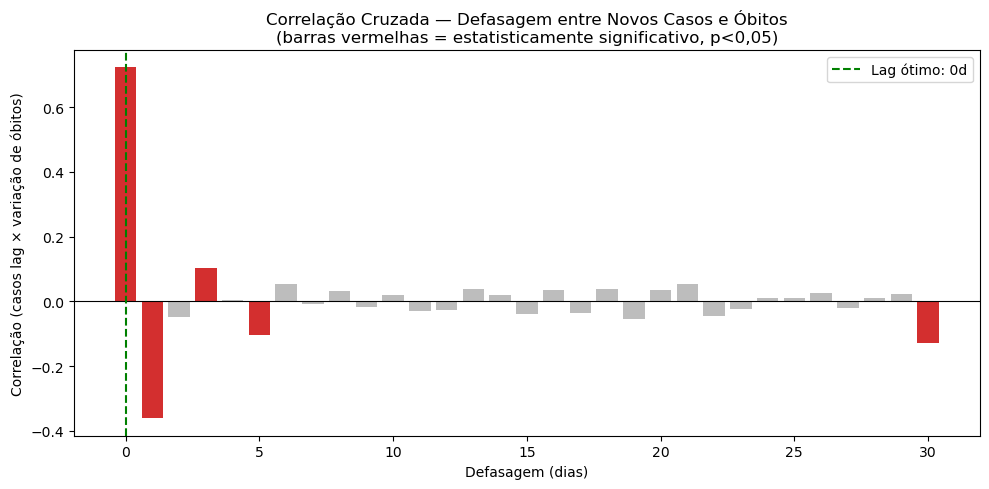

In [69]:
# ── Visualização do perfil de correlação por lag ───────────────────────────────

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(df_lag_co["lag_dias"], df_lag_co["correlacao"],
       color=["#d32f2f" if p < 0.05 else "#bdbdbd" for p in df_lag_co["p_valor"]])
ax.axhline(0, color="black", linewidth=0.8)
ax.axvline(melhor_lag_co["lag_dias"], color="green", linestyle="--",
           label=f"Lag ótimo: {int(melhor_lag_co['lag_dias'])}d")
ax.set_xlabel("Defasagem (dias)")
ax.set_ylabel("Correlação (casos lag × variação de óbitos)")
ax.set_title("Correlação Cruzada — Defasagem entre Novos Casos e Óbitos\n"
             "(barras vermelhas = estatisticamente significativo, p<0,05)")
ax.legend()
plt.tight_layout()
plt.show()

In [70]:
# ── Teste 4: Decomposição por onda epidemiológica ──────────────────────────────
# Mesma estrutura usada para vacinação: testa se a relação casos-óbitos
# é estável dentro de cada onda, ou se varia entre as fases da pandemia
# (o que seria esperado, já que a letalidade mudou entre variantes)

agg_onda_co = (
    sub[sub["state"] != "TOTAL"]
    .groupby(["date", "onda"], as_index=False)
    .agg(
        casos_media=("newCases_mm7", "mean"),
        obitos_media=("newDeaths_mm7", "mean"),
    )
)

correlacoes_onda_co = []
for onda, grupo in agg_onda_co.groupby("onda"):
    if grupo["casos_media"].std() == 0 or len(grupo) < 3:
        continue
    r, p = pearsonr(grupo["casos_media"], grupo["obitos_media"])
    correlacoes_onda_co.append({"onda": onda, "r": r, "p_valor": p, "n_dias": len(grupo)})

df_onda_co = pd.DataFrame(correlacoes_onda_co)
print("=== Teste 4: Correlação por onda epidemiológica ===")
print(df_onda_co.to_string(index=False))
print()
print("Interpretação esperada: diferente da vacinação, aqui é plausível que a")
print("correlação seja positiva e significativa em TODAS as ondas (casos")
print("precedem óbitos biologicamente). O que muda entre ondas é a MAGNITUDE —")
print("uma correlação mais fraca na Ômicron, por exemplo, seria consistente com")
print("menor letalidade da variante (mais casos, proporcionalmente menos óbitos).")

=== Teste 4: Correlação por onda epidemiológica ===
           onda        r      p_valor  n_dias
1_pre_vacinacao 0.824864 2.900084e-80     318
        2_gamma 0.888784 2.077664e-72     210
        3_delta 0.927518 4.047467e-53     122
      4_omicron 0.665908 9.767162e-27     198
     5_pos_pico 0.668976 3.136669e-35     261

Interpretação esperada: diferente da vacinação, aqui é plausível que a
correlação seja positiva e significativa em TODAS as ondas (casos
precedem óbitos biologicamente). O que muda entre ondas é a MAGNITUDE —
uma correlação mais fraca na Ômicron, por exemplo, seria consistente com
menor letalidade da variante (mais casos, proporcionalmente menos óbitos).


In [71]:
# ── Lag ótimo POR ONDA (complementar) ──────────────────────────────────────────
# Testa se o lag ótimo muda entre ondas — por exemplo, se o tempo até o óbito
# diminuiu nas ondas posteriores devido a melhor manejo clínico e vacinação

print("=== Lag ótimo dentro de cada onda ===\n")

for onda in sub["onda"].dropna().unique():
    grupo = (
        sub[(sub["state"] != "TOTAL") & (sub["onda"] == onda)]
        .groupby("date", as_index=False)
        .agg(casos_media=("newCases_mm7", "mean"), obitos_media=("newDeaths_mm7", "mean"))
        .set_index("date")
        .sort_index()
    )
    grupo_diff = grupo.diff().dropna()

    if len(grupo_diff) < 15:
        print(f"{onda}: dados insuficientes (n={len(grupo_diff)})")
        continue

    melhores = []
    for lag in range(0, min(21, len(grupo_diff) - 5)):
        casos_lag = grupo_diff["casos_media"].shift(lag)
        valid = casos_lag.notna() & grupo_diff["obitos_media"].notna()
        if valid.sum() < 10:
            continue
        r, p = pearsonr(casos_lag[valid], grupo_diff["obitos_media"][valid])
        melhores.append((lag, r, p))

    if melhores:
        melhor = max(melhores, key=lambda x: x[1])
        print(f"{onda}: lag ótimo={melhor[0]}d | r={melhor[1]:+.3f} | p={melhor[2]:.4f} | n={len(grupo_diff)}")

=== Lag ótimo dentro de cada onda ===

1_pre_vacinacao: lag ótimo=0d | r=+0.844 | p=0.0000 | n=317
2_gamma: lag ótimo=0d | r=+0.941 | p=0.0000 | n=209
3_delta: lag ótimo=0d | r=+0.862 | p=0.0000 | n=121
4_omicron: lag ótimo=0d | r=+0.456 | p=0.0000 | n=197
5_pos_pico: lag ótimo=0d | r=+0.706 | p=0.0000 | n=260


## 3 — Mapa Coroplético: Mortalidade e Vacinação por Estado

In [49]:
def plot_mapa_coropletico(df, altura=600):
    """
    Mapa coroplético do Brasil colorindo cada estado pela taxa de óbitos
    por 100 mil habitantes.

    Usa a coluna já existente 'deaths_per_100k_inhabitants'.

    Parâmetros
    ----------
    df    : DataFrame com 'state', 'deaths_per_100k_inhabitants'
    altura: altura do mapa em pixels
    """
    # Snapshot: valor máximo acumulado por estado
    df_mapa = (
        df.groupby('state')['deaths_per_100k_inhabitants']
        .max()
        .reset_index()
    )

    fig = px.choropleth(
        df_mapa,
        geojson='https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson',
        locations='state',
        featureidkey='properties.sigla',
        color='deaths_per_100k_inhabitants',
        color_continuous_scale='Reds',
        range_color=(
            df_mapa['deaths_per_100k_inhabitants'].min(),
            df_mapa['deaths_per_100k_inhabitants'].max()
        ),
        labels={'deaths_per_100k_inhabitants': 'Óbitos / 100k hab.'},
        title='<b>Mortalidade por COVID-19 — Óbitos por 100 mil Habitantes</b>',
    )

    fig.update_geos(fitbounds='locations', visible=False, bgcolor='rgba(0,0,0,0)')
    fig.update_layout(
        template='plotly_white',
        height=altura,
        coloraxis_colorbar=dict(
            title='Óbitos<br>/ 100k hab.',
            thicknessmode='pixels', thickness=18,
            lenmode='fraction', len=0.75,
        ),
        margin=dict(l=0, r=0, t=60, b=0),
    )
    fig.show()


plot_mapa_coropletico(sub_estados)

In [50]:
def plot_mapas_obitos_vacinacao(df, altura=650):
    """
    Compara espacialmente:
    - Óbitos por 100 mil habitantes
    - Cobertura vacinal (% população com 1ª dose)

    usando dois mapas lado a lado.
    """

    # Snapshot final por estado
    df_mapa = (
        df.sort_values('date')
          .groupby('state')
          .last()
          .reset_index()
    )

    geojson_url = (
        "https://raw.githubusercontent.com/"
        "codeforamerica/click_that_hood/master/"
        "public/data/brazil-states.geojson"
    )

    fig = make_subplots(
        rows=1,
        cols=2,
        specs=[[{"type": "choropleth"}, {"type": "choropleth"}]],
        subplot_titles=(
            "Óbitos por 100 mil habitantes",
            "Cobertura Vacinal (1ª dose %)"
        ),
        horizontal_spacing=0.05
    )

    # MAPA 1 — ÓBITOS
    fig.add_trace(
        go.Choropleth(
            geojson=geojson_url,
            locations=df_mapa["state"],
            z=df_mapa["deaths_per_100k_inhabitants"],
            featureidkey="properties.sigla",
            colorscale="Reds",
            colorbar=dict(
                title="Óbitos<br>100k",
                x=0.46
            ),
            marker_line_color="black",
            marker_line_width=0.5,
            name="Óbitos"
        ),
        row=1,
        col=1
    )

    # MAPA 2 — VACINAÇÃO
    fig.add_trace(
        go.Choropleth(
            geojson=geojson_url,
            locations=df_mapa["state"],
            z=df_mapa["vaccinated_per_100_inhabitants"],
            featureidkey="properties.sigla",
            colorscale="Greens",
            colorbar=dict(
                title="Vacinação<br>(%)",
                x=1.02
            ),
            marker_line_color="black",
            marker_line_width=0.5,
            name="Vacinação"
        ),
        row=1,
        col=2
    )

    fig.update_geos(
        fitbounds="locations",
        visible=False,
        scope="south america"
    )

    # Necessário para dois mapas independentes
    fig.update_layout(
        title=(
            "<b>COVID-19 no Brasil</b><br>"
            "Comparação entre Mortalidade e Cobertura Vacinal"
        ),
        template="plotly_white",
        height=altura,
        geo=dict(
            domain={"x": [0.0, 0.45], "y": [0, 1]}
        ),
        geo2=dict(
            domain={"x": [0.55, 1.0], "y": [0, 1]}
        ),
        margin=dict(t=80, l=0, r=0, b=0)
    )

    fig.show()

plot_mapas_obitos_vacinacao(sub)

## 4 — Boxplot: Mortalidade por Região

In [51]:
def plot_boxplot_regiao(df, altura=550):
    """
    Boxplot comparando a distribuição de óbitos por 100 mil habitantes
    entre as cinco regiões geográficas do Brasil.

    Usa a coluna já existente 'deaths_per_100k_inhabitants'.

    Parâmetros
    ----------
    df    : DataFrame com 'region', 'deaths_per_100k_inhabitants'
    altura: altura do gráfico em pixels
    """
    df_plot = df.dropna(subset=['deaths_per_100k_inhabitants', 'region'])

    ordem_regioes = ['Norte', 'Nordeste', 'Centro-Oeste', 'Sudeste', 'Sul']
    palette = {
        'Norte':        '#1f77b4',
        'Nordeste':     '#ff7f0e',
        'Centro-Oeste': '#2ca02c',
        'Sudeste':      '#d62728',
        'Sul':          '#9467bd',
    }

    fig = go.Figure()
    for regiao in ordem_regioes:
        df_r = df_plot[df_plot['region'] == regiao]
        fig.add_trace(
            go.Box(
                y=df_r['deaths_per_100k_inhabitants'],
                name=regiao,
                boxpoints='outliers',
                marker_color=palette.get(regiao, 'gray'),
                line_color=palette.get(regiao, 'gray'),
                fillcolor=palette.get(regiao, 'gray'),
                opacity=0.7,
            )
        )

    fig.update_layout(
        title='<b>Distribuição de Mortalidade por Região</b><br>Óbitos por 100k hab.',
        title_font_size=18,
        yaxis_title='Óbitos por 100k habitantes',
        xaxis_title='Região',
        template='plotly_white',
        showlegend=False,
        height=altura,
    )
    fig.show()


plot_boxplot_regiao(sub_estados)

## 5 — Scatter Plot: Cobertura Vacinal × Mortalidade

In [52]:
def plot_scatter_vacina_obito(df, altura=600):
    """
    Scatter plot explorando a correlação entre cobertura da 2ª dose (%) e
    óbitos acumulados por 100k hab., com linha de tendência OLS,
    colorido por região e dimensionado pelo total de casos.

    Usa as colunas já existentes:
        'vaccinated_second_per_100_inhabitants' (% 2ª dose)
        'deaths_per_100k_inhabitants'

    Parâmetros
    ----------
    df    : DataFrame — usa snapshot da última data por estado
    altura: altura do gráfico em pixels
    """
    df_snap = (
        df.sort_values('date')
        .groupby('state')
        .last()
        .reset_index()
        .dropna(subset=['vaccinated_second_per_100_inhabitants', 'deaths_per_100k_inhabitants'])
    )

    # Remove zeros que distorceriam a correlação (estados sem dado de vacina)
    df_snap = df_snap[
        (df_snap['vaccinated_second_per_100_inhabitants'] > 0) &
        (df_snap['deaths_per_100k_inhabitants'] > 0)
    ]

    r, p = stats.pearsonr(
        df_snap['vaccinated_second_per_100_inhabitants'],
        df_snap['deaths_per_100k_inhabitants']
    )

    # Linha de tendência manual com numpy (sem statsmodels)
    x_vals = df_snap['vaccinated_second_per_100_inhabitants'].values
    y_vals = df_snap['deaths_per_100k_inhabitants'].values
    coef   = np.polyfit(x_vals, y_vals, 1)
    x_line = np.linspace(x_vals.min(), x_vals.max(), 200)
    y_line = np.polyval(coef, x_line)

    fig = px.scatter(
        df_snap,
        x='vaccinated_second_per_100_inhabitants',
        y='deaths_per_100k_inhabitants',
        color='region',
        size='totalCases',
        text='state',
        labels={
            'vaccinated_second_per_100_inhabitants': '2ª Dose (% da população)',
            'deaths_per_100k_inhabitants':           'Óbitos por 100k hab.',
            'region':                                'Região',
        },
        title=(
            f'<b>Cobertura Vacinal (2ª Dose) × Mortalidade por Estado</b>'
            f'<br>r de Pearson = {r:.3f}  |  p-valor = {p:.4f}'
        ),
        color_discrete_sequence=px.colors.qualitative.Safe,
        template='plotly_white',
        height=altura,
    )
    fig.update_traces(
        textposition='top center',
        selector=dict(mode='markers+text')
    )
    # Adiciona a reta de tendência manualmente
    fig.add_trace(
        go.Scatter(
            x=x_line, y=y_line,
            mode='lines',
            name=f'Tendência (y = {coef[0]:.2f}x + {coef[1]:.1f})',
            line=dict(color='black', width=2, dash='dash'),
            showlegend=True,
        )
    )
    fig.update_layout(
        title_font_size=17,
        legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='center', x=0.5),
    )
    fig.show()


plot_scatter_vacina_obito(sub_estados)

## 8 — Scatter Temporal com Lag: Vacinação × Óbitos Fututos

In [53]:
def plot_scatter_lag_vacina_obitos(
    df,
    lag_dias=21,
    altura=650
):
    """
    Relaciona cobertura vacinal atual com óbitos futuros (lag epidemiológico),
    permitindo investigar se maior vacinação está associada
    à redução posterior da mortalidade.

    Estratégia:
    ----------
    vacinação(t)  --->  óbitos(t + lag)

    Usa:
        vaccinated_second_per_100_inhabitants
        newDeaths_mm7

    Parâmetros
    ----------
    df        : DataFrame principal
    lag_dias  : defasagem temporal entre vacinação e óbitos
    altura    : altura do gráfico
    """

    df_plot = df.copy()

    # =====================================================
    # ORDENAÇÃO TEMPORAL
    # =====================================================

    df_plot = (
        df_plot
        .sort_values(['state', 'date'])
        .reset_index(drop=True)
    )

    # =====================================================
    # CRIA ÓBITOS FUTUROS
    # =====================================================

    df_plot[f'obitos_futuros_{lag_dias}d'] = (
        df_plot
        .groupby('state')['newDeaths_mm7']
        .shift(-lag_dias)
    )

    # =====================================================
    # REMOVE VALORES INVÁLIDOS
    # =====================================================

    df_plot = df_plot[
        (df_plot['vaccinated_second_per_100_inhabitants'] > 0)
    ].dropna(
        subset=[
            'vaccinated_second_per_100_inhabitants',
            f'obitos_futuros_{lag_dias}d'
        ]
    )

    # =====================================================
    # AGREGA POR ESTADO
    # =====================================================

    df_estado = (
        df_plot
        .groupby(['state', 'region'])
        .agg({
            'vaccinated_second_per_100_inhabitants': 'mean',
            f'obitos_futuros_{lag_dias}d': 'mean',
            'totalCases': 'max'
        })
        .reset_index()
    )

    # =====================================================
    # CORRELAÇÃO
    # =====================================================

    r, p = stats.pearsonr(
        df_estado['vaccinated_second_per_100_inhabitants'],
        df_estado[f'obitos_futuros_{lag_dias}d']
    )

    # =====================================================
    # LINHA DE TENDÊNCIA
    # =====================================================

    x_vals = df_estado['vaccinated_second_per_100_inhabitants'].values
    y_vals = df_estado[f'obitos_futuros_{lag_dias}d'].values

    coef = np.polyfit(x_vals, y_vals, 1)

    x_line = np.linspace(x_vals.min(), x_vals.max(), 200)
    y_line = np.polyval(coef, x_line)

    # =====================================================
    # SCATTER
    # =====================================================

    fig = px.scatter(
        df_estado,
        x='vaccinated_second_per_100_inhabitants',
        y=f'obitos_futuros_{lag_dias}d',
        color='region',
        size='totalCases',
        text='state',
        labels={
            'vaccinated_second_per_100_inhabitants':
                'Cobertura Vacinal — 2ª Dose (%)',

            f'obitos_futuros_{lag_dias}d':
                f'Óbitos MM7 {lag_dias} dias depois',

            'region': 'Região'
        },
        title=(
            f'<b>Vacinação × Óbitos Futuros ({lag_dias} dias)</b>'
            f'<br>Correlação temporal com lag epidemiológico'
            f'<br>r = {r:.3f} | p-valor = {p:.4f}'
        ),
        template='plotly_white',
        color_discrete_sequence=px.colors.qualitative.Safe,
        height=altura
    )

    fig.update_traces(
        textposition='top center'
    )

    # =====================================================
    # RETA DE TENDÊNCIA
    # =====================================================

    fig.add_trace(
        go.Scatter(
            x=x_line,
            y=y_line,
            mode='lines',
            name=f'Tendência (y = {coef[0]:.2f}x + {coef[1]:.2f})',
            line=dict(
                color='black',
                dash='dash',
                width=2
            )
        )
    )

    # =====================================================
    # AJUSTES VISUAIS
    # =====================================================

    fig.update_layout(
        title_font_size=18,
        legend=dict(
            orientation='h',
            yanchor='bottom',
            y=1.02,
            xanchor='center',
            x=0.5
        )
    )

    fig.show()


# =========================================================
# EXECUÇÃO
# =========================================================

plot_scatter_lag_vacina_obitos(
    sub_estados,
    lag_dias=21
)

## 6 — Heatmap de Correlação: Todas as Variáveis Numéricas

In [54]:
def plot_heatmap_correlacao(df, altura=800):
    """
    Heatmap da matriz de correlação de Pearson entre todas as variáveis
    numéricas, útil para detectar multicolinearidade antes da modelagem.
    Exibe apenas o triângulo inferior para evitar redundância.

    Parâmetros
    ----------
    df    : DataFrame completo (sub_estados)
    altura: altura do gráfico em pixels
    """
    # Exclui colunas puramente identificadoras ou derivadas de índice
    colunas_excluir = ['epi_week']
    numericas = df.select_dtypes(include='number').drop(
        columns=[c for c in colunas_excluir if c in df.columns],
        errors='ignore'
    )

    corr = numericas.corr(method='pearson').round(2)

    # Máscara triangular superior
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
    corr_lower = corr.where(~mask)

    fig = go.Figure(
        go.Heatmap(
            z=corr_lower.values,
            x=corr_lower.columns.tolist(),
            y=corr_lower.index.tolist(),
            colorscale='RdBu_r',
            zmid=0, zmin=-1, zmax=1,
            text=corr_lower.round(2).values,
            texttemplate='%{text}',
            textfont=dict(size=8),
            colorbar=dict(title='r de<br>Pearson'),
            hoverongaps=False,
        )
    )
    fig.update_layout(
        title='<b>Heatmap de Correlação — Variáveis Numéricas</b>',
        title_font_size=18,
        template='plotly_white',
        height=altura,
        xaxis=dict(tickangle=-45),
        margin=dict(l=180, b=180),
    )
    fig.show()


plot_heatmap_correlacao(sub_estados)

## 7 — Gráfico de Barras: Ranking de Letalidade por Estado

In [55]:
def plot_barras_letalidade(df, altura=620):
    """
    Gráfico de barras horizontais com o ranking de taxa de letalidade
    por estado, ordenado do maior para o menor.

    Usa a coluna derivada 'taxa_letalidade' (deaths_by_totalCases × 100),
    calculada na célula de preparação.

    Parâmetros
    ----------
    df    : DataFrame com 'state', 'taxa_letalidade', 'region'
    altura: altura do gráfico em pixels
    """
    # Snapshot: última data disponível por estado
    df_snap = (
        df.sort_values('date')
        .groupby('state')
        .last()
        .reset_index()
        .dropna(subset=['taxa_letalidade'])
        .sort_values('taxa_letalidade', ascending=True)  # crescente → barras ordenadas
    )

    mapa_cores = {
        'Norte':        '#1f77b4',
        'Nordeste':     '#ff7f0e',
        'Centro-Oeste': '#2ca02c',
        'Sudeste':      '#d62728',
        'Sul':          '#9467bd',
    }
    cores = df_snap['region'].map(mapa_cores).fillna('#aec7e8').tolist()

    fig = go.Figure(
        go.Bar(
            x=df_snap['taxa_letalidade'],
            y=df_snap['state'],
            orientation='h',
            marker_color=cores,
            text=df_snap['taxa_letalidade'].map('{:.2f}%'.format),
            textposition='outside',
            hovertemplate='%{y}: %{x:.2f}%<extra></extra>',
        )
    )

    media = df_snap['taxa_letalidade'].mean()
    fig.add_vline(
        x=media, line_dash='dash', line_color='black',
        annotation_text=f'Média: {media:.2f}%',
        annotation_position='top right',
    )

    # Legenda manual por região
    for regiao, cor in mapa_cores.items():
        fig.add_trace(
            go.Bar(x=[None], y=[None], marker_color=cor, name=regiao, showlegend=True)
        )

    fig.update_layout(
        title='<b>Ranking de Letalidade por Estado</b><br>Taxa = (Óbitos Totais / Casos Totais) × 100',
        title_font_size=18,
        xaxis_title='Taxa de Letalidade (%)',
        yaxis_title='Estado',
        template='plotly_white',
        height=altura,
        margin=dict(r=90),
        barmode='overlay',
        legend=dict(
            title='Região',
            orientation='v',
            yanchor='bottom', y=0.01,
            xanchor='right',  x=0.99,
        ),
    )
    fig.show()


plot_barras_letalidade(sub_estados)

## 8 — Histograma da Variável Resposta: deaths_per_100k_inhabitants

In [56]:
def plot_histograma_variavel_resposta(df, altura=620):
    """
    Histograma de 'deaths_per_100k_inhabitants' em escala original e
    após transformação log1p, dispostos lado a lado.

    Exibe também estatísticas descritivas (média, mediana, assimetria)
    e uma curva KDE sobreposta para avaliar a forma da distribuição.
    A comparação entre os dois painéis serve de base para decidir se
    a transformação log1p será aplicada à variável resposta no EP3.

    Parâmetros
    ----------
    df    : DataFrame com coluna 'deaths_per_100k_inhabitants' (sub_estados)
    altura: altura do gráfico em pixels
    """
    coluna = 'deaths_per_100k_inhabitants'
    serie = df[coluna].dropna()
    serie_log = np.log1p(serie)

    def stats_label(s, nome):
        return (
            f"<b>{nome}</b><br>"
            f"Média: {s.mean():.2f}<br>"
            f"Mediana: {s.median():.2f}<br>"
            f"Assimetria: {s.skew():.2f}<br>"
            f"Curtose: {s.kurt():.2f}"
        )

    fig = make_subplots(
        rows=1, cols=2,
        subplot_titles=(
            '<b>Escala Original</b>',
            '<b>Após Transformação log1p</b>'
        ),
        horizontal_spacing=0.12
    )

    cor_original = '#636EFA'
    cor_log      = '#EF553B'

    for col_idx, (s, cor, rotulo) in enumerate(
        [
            (serie,     cor_original, 'Original'),
            (serie_log, cor_log,      'log1p')
        ],
        start=1
    ):
        # Histograma
        fig.add_trace(
            go.Histogram(
                x=s,
                nbinsx=60,
                name=rotulo,
                marker_color=cor,
                opacity=0.75,
                histnorm='probability density',
                showlegend=False,
            ),
            row=1, col=col_idx
        )

        # Curva KDE via numpy
        kde_x = np.linspace(s.min(), s.max(), 300)
        kernel = stats.gaussian_kde(s, bw_method='scott')
        kde_y  = kernel(kde_x)

        fig.add_trace(
            go.Scatter(
                x=kde_x,
                y=kde_y,
                mode='lines',
                name=f'KDE — {rotulo}',
                line=dict(color=cor, width=3),
                showlegend=True,
            ),
            row=1, col=col_idx
        )

        # Linha vertical: média
        fig.add_vline(
            x=s.mean(),
            line_dash='dash',
            line_color='black',
            line_width=1.5,
            annotation_text=f'Média={s.mean():.1f}',
            annotation_position='top right',
            row=1, col=col_idx  # type: ignore[call-arg]
        )

        # Linha vertical: mediana
        fig.add_vline(
            x=s.median(),
            line_dash='dot',
            line_color='gray',
            line_width=1.5,
            annotation_text=f'Mediana={s.median():.1f}',
            annotation_position='top left',
            row=1, col=col_idx  # type: ignore[call-arg]
        )

        # Anotação com estatísticas no canto
        fig.add_annotation(
            xref='x domain' if col_idx == 1 else 'x2 domain',
            yref='y domain' if col_idx == 1 else 'y2 domain',
            x=0.98, y=0.97,
            text=stats_label(s, rotulo),
            showarrow=False,
            align='right',
            bgcolor='rgba(255,255,255,0.85)',
            bordercolor='lightgray',
            borderwidth=1,
            font=dict(size=11),
            row=1, col=col_idx
        )

    fig.update_layout(
        title=(
            '<b>Distribuição da Variável Resposta — '
            'deaths_per_100k_inhabitants</b>'
            '<br>Comparação: escala original vs. transformação log1p'
        ),
        title_font_size=17,
        template='plotly_white',
        height=altura,
        legend=dict(
            orientation='h',
            yanchor='bottom', y=1.04,
            xanchor='center', x=0.5
        ),
        bargap=0.02,
    )

    fig.update_xaxes(title_text='Óbitos por 100k hab.', row=1, col=1)
    fig.update_xaxes(title_text='log1p(Óbitos por 100k hab.)', row=1, col=2)
    fig.update_yaxes(title_text='Densidade', row=1, col=1)

    fig.show()


plot_histograma_variavel_resposta(sub_estados)

## 9 — Análise por Onda Epidemiológica

In [57]:
def plot_analise_por_onda(df, altura=800):
    """
    Análise comparativa da variável 'onda' em três dimensões:

    Painel 1 (linha): evolução temporal da mediana de novos óbitos
    (MM7) por onda e região, permitindo comparar a gravidade de
    cada período entre as regiões do Brasil.

    Painel 2 (boxplot): distribuição de deaths_per_100k por onda,
    revelando dispersão e outliers em cada período epidemiológico.

    Painel 3 (barras empilhadas): cobertura vacinal média da 1ª dose
    por onda e região, evidenciando o nível de imunização ao longo
    das fases da pandemia.

    Parâmetros
    ----------
    df    : DataFrame com 'onda', 'region', 'date',
            'newDeaths_mm7', 'deaths_per_100k_inhabitants',
            'vaccinated_per_100_inhabitants'  (sub_estados)
    altura: altura total do gráfico em pixels
    """

    if 'onda' not in df.columns:
        df = df.copy()
        df['onda'] = df['date'].apply(classificar_onda)

    # Ordem e rótulos legíveis
    ordem_ondas = [
        '1_pre_vacinacao',
        '2_gamma',
        '3_delta',
        '4_omicron',
        '5_pos_pico',
    ]
    rotulos_ondas = {
        '1_pre_vacinacao': 'Pré-vacinação',
        '2_gamma':         'Gamma',
        '3_delta':         'Delta',
        '4_omicron':       'Ômicron',
        '5_pos_pico':      'Pós-pico',
    }
    df = df.copy()
    df['onda_label'] = df['onda'].map(rotulos_ondas)

    ordem_labels = [rotulos_ondas[o] for o in ordem_ondas]
    regioes       = ['Norte', 'Nordeste', 'Centro-Oeste', 'Sudeste', 'Sul']

    mapa_cores_regiao = {
        'Norte':        '#1f77b4',
        'Nordeste':     '#ff7f0e',
        'Centro-Oeste': '#2ca02c',
        'Sudeste':      '#d62728',
        'Sul':          '#9467bd',
    }

    # Paleta para as ondas (boxplot / barras)
    cores_ondas = px.colors.qualitative.Safe

    # =====================================================
    # SUBPLOTS
    # =====================================================
    fig = make_subplots(
        rows=3, cols=1,
        subplot_titles=(
            '<b>Mediana de Novos Óbitos (MM7) por Onda e Região</b>',
            '<b>Distribuição de Novos Óbitos Diários (MM7) por Onda Epidemiológica</b>',
            '<b>Cobertura Vacinal Média (1ª Dose %) por Onda e Região</b>',
        ),
        vertical_spacing=0.10,
        row_heights=[0.36, 0.34, 0.30],
    )

    # =====================================================
    # PAINEL 1 — Linha: mediana de newDeaths_mm7 por onda × região
    # =====================================================
    df_p1 = (
        df.dropna(subset=['newDeaths_mm7', 'onda_label', 'region'])
        .groupby(['onda_label', 'region'], observed=True)['newDeaths_mm7']
        .median()
        .reset_index()
    )
    df_p1['onda_label'] = pd.Categorical(
        df_p1['onda_label'], categories=ordem_labels, ordered=True
    )
    df_p1 = df_p1.sort_values('onda_label')

    for regiao in regioes:
        sub_r = df_p1[df_p1['region'] == regiao]
        fig.add_trace(
            go.Scatter(
                x=sub_r['onda_label'],
                y=sub_r['newDeaths_mm7'],
                mode='lines+markers',
                name=regiao,
                legendgroup=regiao,
                showlegend=True,
                line=dict(color=mapa_cores_regiao[regiao], width=2.5),
                marker=dict(size=8),
            ),
            row=1, col=1
        )

    # =====================================================
    # PAINEL 2 — Boxplot: deaths_per_100k por onda
    # =====================================================
    for i, onda_label in enumerate(ordem_labels):
        sub_o = df[df['onda_label'] == onda_label]['newDeaths_mm7'].dropna()
        fig.add_trace(
            go.Box(
                y=sub_o,
                name=onda_label,
                legendgroup=onda_label,
                showlegend=False,
                marker_color=cores_ondas[i % len(cores_ondas)],
                boxmean='sd',
                line_width=1.5,
            ),
            row=2, col=1
        )

    # =====================================================
    # PAINEL 3 — Barras agrupadas: vacinação média por onda × região
    # =====================================================
    df_p3 = (
        df.dropna(subset=['vaccinated_per_100_inhabitants', 'onda_label', 'region'])
        .groupby(['onda_label', 'region'], observed=True)['vaccinated_per_100_inhabitants']
        .mean()
        .reset_index()
    )
    df_p3['onda_label'] = pd.Categorical(
        df_p3['onda_label'], categories=ordem_labels, ordered=True
    )
    df_p3 = df_p3.sort_values('onda_label')

    for regiao in regioes:
        sub_r = df_p3[df_p3['region'] == regiao]
        fig.add_trace(
            go.Bar(
                x=sub_r['onda_label'],
                y=sub_r['vaccinated_per_100_inhabitants'],
                name=regiao,
                legendgroup=regiao,
                showlegend=False,
                marker_color=mapa_cores_regiao[regiao],
                opacity=0.85,
            ),
            row=3, col=1
        )

    # =====================================================
    # AJUSTES VISUAIS
    # =====================================================
    fig.update_layout(
        title=(
            '<b>Análise Comparativa por Onda Epidemiológica</b>'
            '<br>Mortalidade, distribuição de óbitos e vacinação '
            'em cada fase da pandemia'
        ),
        title_font_size=17,
        template='plotly_white',
        height=altura,
        barmode='group',
        legend=dict(
            title='Região',
            orientation='v',
            yanchor='middle', y=0.85,
            xanchor='left',   x=1.01,
        ),
        margin=dict(r=130),
    )

    fig.update_yaxes(title_text='Mediana Óbitos MM7',       row=1, col=1)
    fig.update_yaxes(title_text='Novos Óbitos Diários MM7', row=2, col=1)
    fig.update_yaxes(title_text='1ª Dose (% pop.)',          row=3, col=1)

    fig.show()

plot_analise_por_onda(sub)

## 10 — Limiar de Vacinação e Mortalidade

In [58]:
def plot_limiar_vacinacao(df, largura_bin=5, coluna_obitos='newDeaths_mm7',
                          coluna_vacina='vaccinated_second_per_100_inhabitants',
                          altura=750):
    """
    Investiga o limiar de cobertura vacinal (2ª dose) a partir do qual
    a mortalidade cai de forma significativa — questão (a) do estudo.
 
    Metodologia
    -----------
    1. Filtra apenas o período pós-vacinação (vacina > 0).
    2. Divide a cobertura vacinal em bins de largura fixa (padrão: 5 pp).
    3. Calcula mediana e IQR de newDeaths_mm7 por bin.
    4. Detecta o limiar como o bin de maior queda relativa
       (Δ% negativo entre medianas consecutivas).
    5. Apresenta três painéis complementares:
       - Painel 1 (curva + IC): mediana suavizada por bin, com faixa
         IQR e linha vertical marcando o limiar detectado.
       - Painel 2 (barras): contagem de observações por bin —
         revela onde há dados suficientes para confiar na estimativa.
       - Painel 3 (scatter por região): scatter vacinação × óbitos
         colorido por região, com linha de limiar, para verificar se
         o limiar é consistente entre regiões ou apenas nacional.
 
    Parâmetros
    ----------
    df             : DataFrame (sub_estados)
    largura_bin    : largura de cada intervalo de cobertura vacinal (pp)
    coluna_obitos  : variável resposta (padrão: newDeaths_mm7)
    coluna_vacina  : cobertura vacinal (padrão: vaccinated_second_per_100)
    altura         : altura total do gráfico em pixels
    """
 
    # =====================================================
    # PREPARAÇÃO
    # =====================================================
    df = df.copy()
    df = df[df[coluna_vacina] > 0].dropna(subset=[coluna_vacina, coluna_obitos])
    df = df[df[coluna_obitos] >= 0]
 
    # Bins de vacinação com passo fixo
    vacc_max  = int(np.ceil(df[coluna_vacina].max() / largura_bin) * largura_bin)
    bins      = np.arange(0, vacc_max + largura_bin, largura_bin)
    midpoints = bins[:-1] + largura_bin / 2
 
    df['vacc_bin']  = pd.cut(df[coluna_vacina], bins=bins, labels=midpoints, right=False)
    df['vacc_bin']  = df['vacc_bin'].astype(float)
 
    # =====================================================
    # ESTATÍSTICAS POR BIN
    # =====================================================
    resumo = (
        df.groupby('vacc_bin', observed=True)[coluna_obitos]
        .agg(
            mediana='median',
            q25=lambda x: x.quantile(0.25),
            q75=lambda x: x.quantile(0.75),
            n='count'
        )
        .reset_index()
        .sort_values('vacc_bin')
    )
 
    # Remove bins com menos de 10 obs (ruído)
    resumo = resumo[resumo['n'] >= 10].reset_index(drop=True)
 
    # =====================================================
    # DETECÇÃO DO LIMIAR
    # =====================================================
    # Maior queda relativa entre medianas consecutivas
    resumo['delta_rel'] = resumo['mediana'].pct_change()          # Δ%
    idx_limiar  = resumo['delta_rel'].idxmin()                    # bin da maior queda
    limiar_vacc = float(resumo.loc[idx_limiar, 'vacc_bin'])
    limiar_med  = float(resumo.loc[idx_limiar, 'mediana'])
 
    queda_pct   = abs(resumo.loc[idx_limiar, 'delta_rel']) * 100  # % de queda
 
    # =====================================================
    # CORES
    # =====================================================
    # =====================================================
    # FIGURA
    # =====================================================
    fig = make_subplots(
        rows=2, cols=1,
        subplot_titles=(
            '<b>Mediana de Novos Óbitos (MM7) por Cobertura Vacinal (2ª Dose)</b>',
            '<b>Número de Observações por Bin — confiabilidade da estimativa</b>',
        ),
        vertical_spacing=0.12,
        row_heights=[0.72, 0.28],
    )
 
    # =========================================================
    # PAINEL 1 — Curva de mediana + faixa IQR + limiar
    # =========================================================
 
    # Faixa IQR
    fig.add_trace(
        go.Scatter(
            x=list(resumo['vacc_bin']) + list(resumo['vacc_bin'])[::-1],
            y=list(resumo['q75'])      + list(resumo['q25'])[::-1],
            fill='toself',
            fillcolor='rgba(99, 110, 250, 0.15)',
            line=dict(color='rgba(0,0,0,0)'),
            name='IQR (25%–75%)',
            showlegend=True,
        ),
        row=1, col=1
    )
 
    # Curva de mediana
    fig.add_trace(
        go.Scatter(
            x=resumo['vacc_bin'],
            y=resumo['mediana'],
            mode='lines+markers',
            name='Mediana de novos óbitos MM7',
            line=dict(color='#636EFA', width=3),
            marker=dict(size=7, color='#636EFA'),
        ),
        row=1, col=1
    )
 
    # Anotação do ponto de limiar
    fig.add_trace(
        go.Scatter(
            x=[limiar_vacc],
            y=[limiar_med],
            mode='markers',
            name=f'Limiar detectado: {limiar_vacc:.0f}%',
            marker=dict(
                size=14, color='crimson',
                symbol='diamond',
                line=dict(width=2, color='white')
            ),
        ),
        row=1, col=1
    )
 
    # Linha vertical do limiar — painel 1
    fig.add_vline(
        x=limiar_vacc,
        line_dash='dash',
        line_color='crimson',
        line_width=2,
        annotation_text=(
            f'  Limiar: {limiar_vacc:.0f}% 2ª dose<br>'
            f'  Queda de {queda_pct:.1f}% na mediana'
        ),
        annotation_position='top right',
        annotation_font_color='crimson',
        row=1, col=1
    )
 
    # =========================================================
    # PAINEL 2 — Contagem de obs por bin
    # =========================================================
    fig.add_trace(
        go.Bar(
            x=resumo['vacc_bin'],
            y=resumo['n'],
            name='Observações por bin',
            marker_color=[
                'crimson' if v == limiar_vacc else 'rgba(99,110,250,0.5)'
                for v in resumo['vacc_bin']
            ],
            showlegend=False,
        ),
        row=2, col=1
    )
    fig.add_vline(
        x=limiar_vacc,
        line_dash='dash',
        line_color='crimson',
        line_width=1.5,
        row=2, col=1
    )
 
    # =========================================================
    # LAYOUT
    # =========================================================
    fig.update_layout(
        title=f'<b>Limiar de Vacinação e Mortalidade por COVID-19</b>',
        title_font_size=17,
        template='plotly_white',
        height=altura,
        legend=dict(
            orientation='v',
            yanchor='top',    y=0.99,
            xanchor='right',  x=0.99,
            bgcolor='rgba(255,255,255,0.85)',
            bordercolor='lightgray',
            borderwidth=1,
            font=dict(size=12),
        ),
        margin=dict(t=60, r=40),
        bargap=0.1,
        annotations=[
            dict(
                text=(
                    f'Maior queda detectada em ~{limiar_vacc:.0f}% de 2ª dose '
                    f'({queda_pct:.1f}% de redução na mediana)'
                ),
                xref='paper', yref='paper',
                x=0, y=1.04,
                xanchor='left', yanchor='bottom',
                showarrow=False,
                font=dict(size=12, color='gray'),
            )
        ],
    )
 
    fig.update_xaxes(title_text='2ª Dose (% da população)', row=1, col=1)
    fig.update_xaxes(title_text='2ª Dose (% da população)', row=2, col=1)
 
    fig.update_yaxes(title_text='Mediana Novos Óbitos MM7', row=1, col=1)
    fig.update_yaxes(title_text='Nº observações',           row=2, col=1)
 
    fig.show()
 
    # =========================================================
    # PRINT DO RESULTADO
    # =========================================================
    print("\n" + "=" * 52)
    print("LIMIAR DE VACINAÇÃO — RESULTADO")
    print("=" * 52)
    print(f"  Variável vacinal : {coluna_vacina}")
    print(f"  Variável resposta: {coluna_obitos}")
    print(f"  Largura do bin   : {largura_bin} pp")
    print(f"\n  Limiar detectado : {limiar_vacc:.0f}% de 2ª dose")
    print(f"  Queda na mediana : {queda_pct:.1f}% em relação ao bin anterior")
    print(f"  Mediana pré-limiar : "
          f"{float(resumo.loc[idx_limiar - 1, 'mediana']) if idx_limiar > 0 else 'N/A':.1f} óbitos MM7")
    print(f"  Mediana pós-limiar : {limiar_med:.1f} óbitos MM7")
    print("=" * 52 + "\n")
 
    return {
        'limiar_vacc_pct': limiar_vacc,
        'queda_pct':       queda_pct,
        'resumo_bins':     resumo,
    }
 
 
resultado_limiar = plot_limiar_vacinacao(sub_estados)


LIMIAR DE VACINAÇÃO — RESULTADO
  Variável vacinal : vaccinated_second_per_100_inhabitants
  Variável resposta: newDeaths_mm7
  Largura do bin   : 5 pp

  Limiar detectado : 18% de 2ª dose
  Queda na mediana : 59.3% em relação ao bin anterior
  Mediana pré-limiar : 30.6 óbitos MM7
  Mediana pós-limiar : 12.4 óbitos MM7



# Visão de correlação Vacina X Obitos pela sem visão nacional

In [78]:
# ── Teste: Limiar de vacinação x óbitos em MG, com base COMPLETA (não amostrada) ──
# Diferente da análise original (que usava 'sub', amostra de 30%), este teste
# carrega a base bruta completa do wcota/covid19br, filtra apenas MG, e busca
# o limiar de mudança DENTRO de cada onda separadamente — controlando, assim,
# pela tendência temporal que invalidou a análise nacional agregada original.

import pandas as pd
import numpy as np

# Carrega a base completa (ajuste o caminho/URL conforme a fonte original usada no EP1/EP2)
data_completa = pd.read_csv(r"..\data\raw\cases-brazil-states.csv")
data_completa["date"] = pd.to_datetime(data_completa["date"])

mg = data_completa[data_completa["state"] == "MG"].sort_values("date").reset_index(drop=True)

print(f"Total de registros para MG (base completa): {len(mg)}")
print(f"Período: {mg['date'].min().date()} a {mg['date'].max().date()}")

Total de registros para MG (base completa): 1106
Período: 2020-03-08 a 2023-03-18


In [79]:
# ── Preparação: clip de negativos, médias móveis, onda (mesmo pipeline já validado) ──

mg["newDeaths"] = mg["newDeaths"].clip(lower=0)
mg["newCases"] = mg["newCases"].clip(lower=0)

mg["newDeaths_mm7"] = mg["newDeaths"].rolling(7, min_periods=1).mean()
mg["newCases_mm7"] = mg["newCases"].rolling(7, min_periods=1).mean()

# Reaproveita a mesma função classificar_onda já usada no notebook principal
mg["onda"] = mg["date"].apply(classificar_onda)

# Vacinação 1ª dose já vem em vaccinated_per_100_inhabitants na base bruta
print(mg[["date", "onda", "vaccinated_per_100_inhabitants", "newDeaths_mm7"]].describe())

                      date  vaccinated_per_100_inhabitants  newDeaths_mm7
count                 1106                      790.000000    1106.000000
mean   2021-09-11 12:00:00                       64.681367      59.301989
min    2020-03-08 00:00:00                        0.000020       0.000000
25%    2020-12-09 06:00:00                       48.361795      11.714286
50%    2021-09-11 12:00:00                       80.471010      28.642857
75%    2022-06-14 18:00:00                       85.452240      75.928571
max    2023-03-18 00:00:00                       86.842320     339.571429
std                    NaN                       29.369981      71.312415


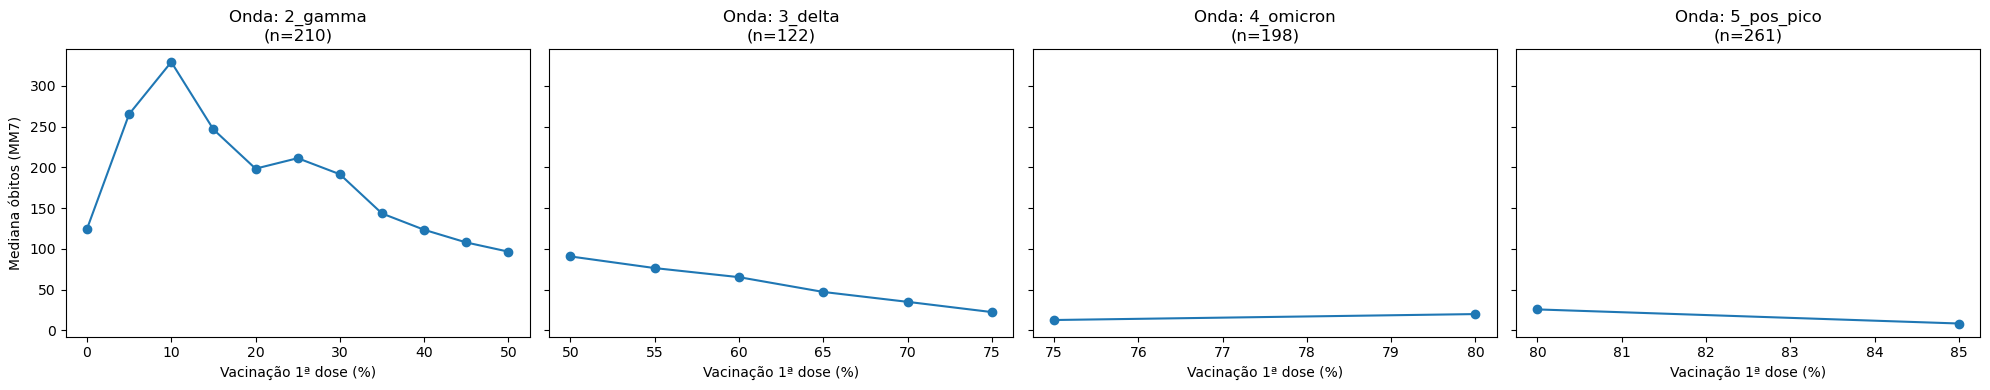

In [81]:
# ── Teste de limiar DENTRO de cada onda (controle de tendência temporal) ──────
# Busca um ponto de mudança na relação vacinação-óbitos separadamente em cada
# onda. Se a queda abrupta só aparecer quando todas as ondas são misturadas
# (como no teste original), e não dentro de cada onda isolada, confirma que
# o "limiar" é artefato de transição entre ondas, não um efeito vacinal real.

import matplotlib.pyplot as plt

ondas_com_vacinacao = mg[mg["vaccinated_per_100_inhabitants"] > 0]["onda"].unique()

fig, axes = plt.subplots(1, len(ondas_com_vacinacao), figsize=(5 * len(ondas_com_vacinacao), 4), sharey=True)
if len(ondas_com_vacinacao) == 1:
    axes = [axes]

for ax, onda in zip(axes, sorted(ondas_com_vacinacao)):
    grupo = mg[mg["onda"] == onda].copy()
    if grupo["vaccinated_per_100_inhabitants"].std() == 0 or len(grupo) < 10:
        continue

    # Agrupa por faixas de 5% de cobertura vacinal, calcula mediana de óbitos
    grupo["faixa_vac"] = (grupo["vaccinated_per_100_inhabitants"] // 5) * 5
    mediana_por_faixa = grupo.groupby("faixa_vac")["newDeaths_mm7"].median()

    ax.plot(mediana_por_faixa.index, mediana_por_faixa.values, marker="o")
    ax.set_title(f"Onda: {onda}\n(n={len(grupo)})")
    ax.set_xlabel("Vacinação 1ª dose (%)")

axes[0].set_ylabel("Mediana óbitos (MM7)")
plt.tight_layout()
plt.show()

In [82]:
# ── Teste estatístico de ponto de mudança (changepoint) dentro de cada onda ───
# Usa regressão segmentada simples: testa, para cada possível ponto de corte
# na cobertura vacinal, se dividir os dados em dois grupos (antes/depois do
# corte) explica melhor a variação de óbitos do que uma única reta — e reporta
# o ponto de corte com melhor ajuste (menor soma de quadrados residual).

from itertools import product

def melhor_changepoint(vacinacao, obitos, min_pontos=15):
    """Testa pontos de corte e retorna o que minimiza o erro quadrático total
    de dois ajustes lineares separados (antes/depois do corte)."""
    pontos_candidatos = np.percentile(vacinacao, np.arange(10, 91, 5))
    melhor_erro = np.inf
    melhor_corte = None

    for corte in pontos_candidatos:
        antes = vacinacao <= corte
        depois = vacinacao > corte
        if antes.sum() < min_pontos or depois.sum() < min_pontos:
            continue

        erro_total = 0
        for mask in [antes, depois]:
            x, y = vacinacao[mask], obitos[mask]
            if len(x) < 2 or x.std() == 0:
                erro_total += np.sum((y - y.mean()) ** 2)
                continue
            coef = np.polyfit(x, y, 1)
            pred = np.polyval(coef, x)
            erro_total += np.sum((y - pred) ** 2)

        if erro_total < melhor_erro:
            melhor_erro = erro_total
            melhor_corte = corte

    return melhor_corte, melhor_erro

print("=== Changepoint de vacinação x óbitos, dentro de cada onda (MG) ===\n")
for onda in sorted(ondas_com_vacinacao):
    grupo = mg[mg["onda"] == onda].copy()
    if grupo["vaccinated_per_100_inhabitants"].std() == 0 or len(grupo) < 30:
        print(f"{onda}: dados insuficientes para teste de changepoint")
        continue

    corte, erro = melhor_changepoint(
        grupo["vaccinated_per_100_inhabitants"].values,
        grupo["newDeaths_mm7"].values
    )
    print(f"{onda}: changepoint em vacinação = {corte:.1f}% (n={len(grupo)})" if corte else f"{onda}: nenhum changepoint claro encontrado")

=== Changepoint de vacinação x óbitos, dentro de cada onda (MG) ===

2_gamma: nenhum changepoint claro encontrado
3_delta: changepoint em vacinação = 66.7% (n=122)
4_omicron: changepoint em vacinação = 80.8% (n=198)
5_pos_pico: changepoint em vacinação = 85.8% (n=261)
